In [13]:
import yfinance as yf
import pandas as pd

# Show all rows when printing
pd.set_option("display.max_rows", None)

# Example ticker (change to your stock symbol)
ticker_symbol = "AAPL"

# Fetch last 100 trading days
data = yf.download(ticker_symbol, period="100d", interval="1d")

# Print every row
print(data)


[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2025-05-07  195.770798  198.953011  192.778123  198.683666   68536700
2025-05-08  197.007782  199.561529  194.204631  197.237216   50478900
2025-05-09  198.045242  200.050329  197.057654  198.514096   36453900
2025-05-12  210.551041  211.030507  206.515627  210.730845   63775800
2025-05-13  212.688614  213.158082  208.763076  210.191448   51909300
2025-05-14  212.089294  213.697470  210.341278  212.189172   49325800
2025-05-15  211.210297  212.718595  209.302458  210.710863   45029500
2025-05-16  211.020508  212.329036  209.532207  212.119267   54737900
2025-05-19  208.543320  209.242523  204.028439  207.674311   46140500
2025-05-20  206.625504  208.233679  204.797576  207.434583   42496600
2025-05-21  201.860901  206.805286  200.482476  204.937411   59211800
2025-05-22  201.1317

[*********************100%***********************]  1 of 1 completed


Downloaded data shape: (3959, 5)
Computing technical indicators...
Dropped 49 rows with NaN values
Final dataset shape: (3910, 25)
Using 22 features
Target: Target_Return
Training data: 3127 samples
Test data: 782 samples
Creating sequences with time_steps = 10
Training sequences shape: X=(3117, 10, 22), y=(3117, 1)
Test sequences shape: X=(772, 10, 22), y=(772, 1)
Model: input_size=22, hidden_size=64, num_layers=2
Training model for up to 150 epochs...
Epoch [20/150], Train Loss: 0.999147, Val Loss: 0.980907
Epoch [40/150], Train Loss: 0.997269, Val Loss: 0.981633
Early stopping at epoch 44

Evaluating model on test set...
Test Loss: 0.981769

=== COMPREHENSIVE TEST METRICS ===
Root Mean Squared Error (RMSE): $3.33
Mean Absolute Error (MAE): $2.28
Mean Absolute Percentage Error (MAPE): 1.21%
Direction Accuracy: 52.6%
Correlation Coefficient: 0.9946
Predictions within 1%: 56.6%
Predictions within 3%: 92.1%
Predictions within 5%: 98.4%

=== LAST 15 PREDICTIONS ===
2025-09-08: Predicted 

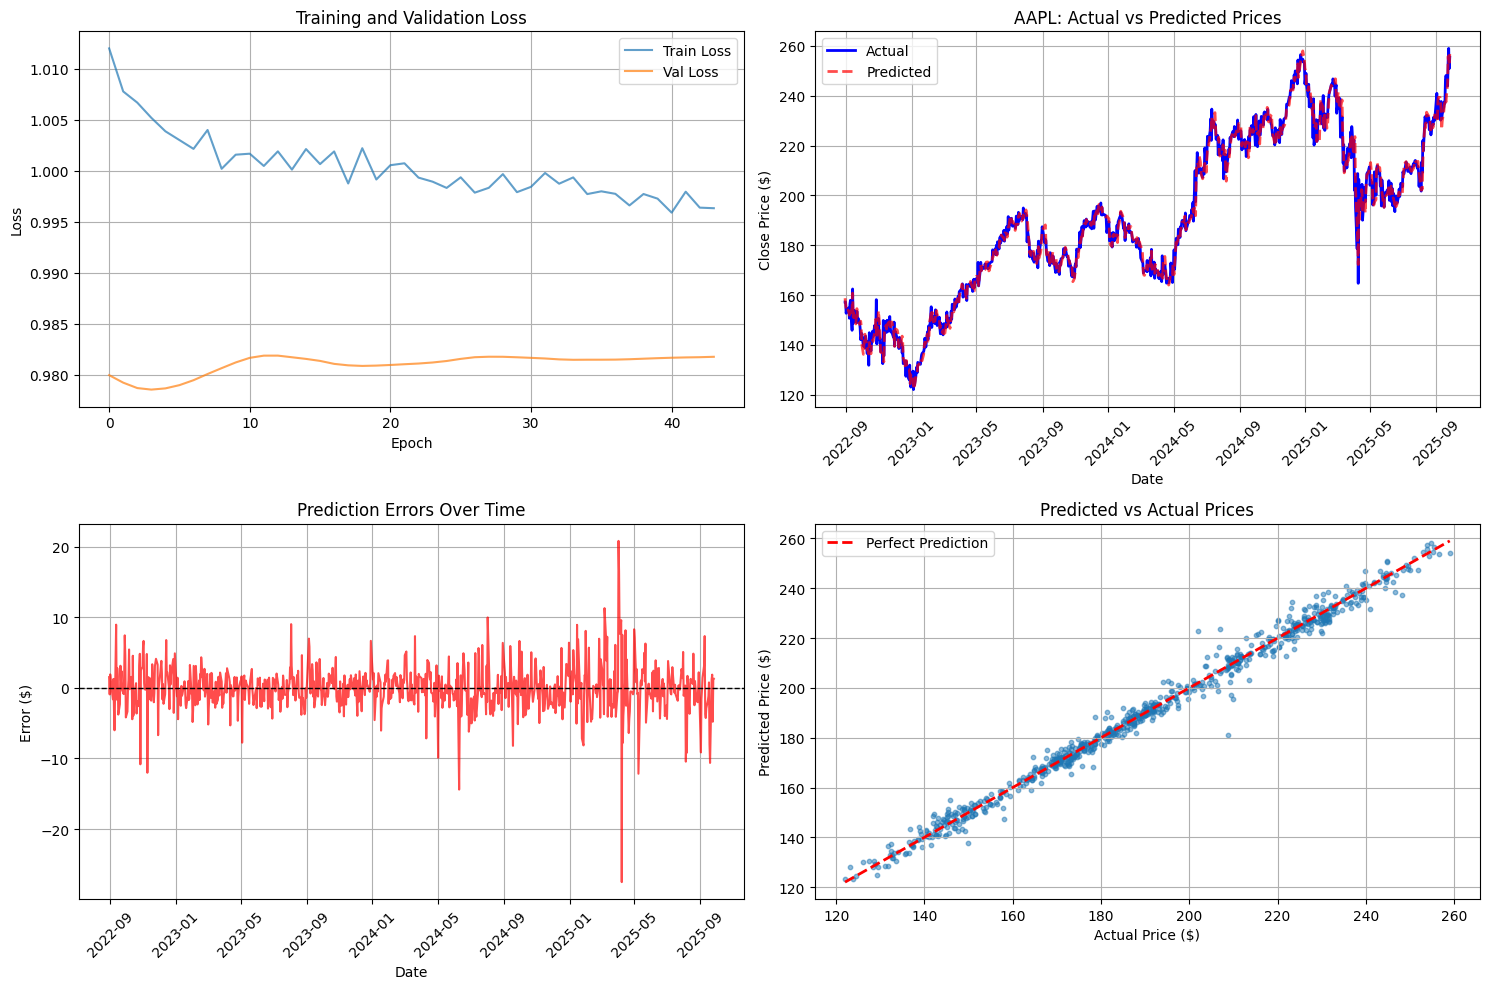


Making future prediction...
Current price: $255.46
Predicted return: -0.02%
Predicted next close price: $255.40
Predicted change: $-0.06

Model saved as AAPL_balanced_lstm.pth
Training complete!


In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pickle
import yfinance as yf
import talib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Fetch latest data for the ticker
ticker = 'AAPL'
start_date = '2010-01-01'
end_date = '2025-09-30'

print(f"Downloading {ticker} data from {start_date} to {end_date}...")
df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)

print(f"Downloaded data shape: {df.shape}")

if df.empty:
    raise ValueError("No data downloaded. Check ticker symbol and date range.")

# Flatten MultiIndex columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Balanced technical indicators - not too many
print("Computing technical indicators...")
close_prices = np.array(df['Close'].values, dtype=np.float64).flatten()
high_prices = np.array(df['High'].values, dtype=np.float64).flatten()
low_prices = np.array(df['Low'].values, dtype=np.float64).flatten()
volume = np.array(df['Volume'].values, dtype=np.float64).flatten()

# Core momentum indicators
df['RSI_14'] = talib.RSI(close_prices, timeperiod=14)
macd, macds, macdh = talib.MACD(close_prices, fastperiod=12, slowperiod=26, signalperiod=9)
df['MACD'] = macd
df['MACD_Signal'] = macds
df['MACD_Hist'] = macdh

# Volatility
df['ATR'] = talib.ATR(high_prices, low_prices, close_prices, timeperiod=14)

# Trend indicators
df['SMA_20'] = talib.SMA(close_prices, timeperiod=20)
df['SMA_50'] = talib.SMA(close_prices, timeperiod=50)
df['EMA_12'] = talib.EMA(close_prices, timeperiod=12)

# Bollinger Bands
upper, middle, lower = talib.BBANDS(close_prices, timeperiod=20)
df['BB_Upper'] = upper
df['BB_Lower'] = lower
df['BB_Position'] = (close_prices - lower) / (upper - lower + 1e-8)  # Normalized position

# Volume
df['Volume_SMA'] = talib.SMA(volume, timeperiod=20)
df['Volume_Ratio'] = volume / (df['Volume_SMA'] + 1e-8)

# Price momentum
df['ROC_10'] = talib.ROC(close_prices, timeperiod=10)
df['MOM_10'] = talib.MOM(close_prices, timeperiod=10)

# Returns
df['Returns_1d'] = df['Close'].pct_change(1)
df['Returns_5d'] = df['Close'].pct_change(5)

# Volatility
df['Volatility_20d'] = df['Close'].rolling(window=20).std() / df['Close']

# Price relative to moving averages
df['Close_to_SMA20'] = (df['Close'] - df['SMA_20']) / df['SMA_20']
df['Close_to_SMA50'] = (df['Close'] - df['SMA_50']) / df['SMA_50']

# Drop rows with NaN
initial_len = len(df)
df = df.dropna()
print(f"Dropped {initial_len - len(df)} rows with NaN values")
print(f"Final dataset shape: {df.shape}")

if len(df) < 100:
    raise ValueError("Not enough data after removing NaN values")

# KEY CHANGE: Predict returns instead of absolute prices
# This helps the model generalize better to different price levels
df['Target_Return'] = df['Close'].pct_change(1).shift(-1)  # Next day's return
df = df.dropna()

# Feature set - balanced
features = [
    'Open', 'High', 'Low', 'Volume',
    'RSI_14', 'MACD', 'MACD_Hist', 'ATR',
    'SMA_20', 'SMA_50', 'EMA_12',
    'BB_Upper', 'BB_Lower', 'BB_Position',
    'Volume_Ratio', 'ROC_10', 'MOM_10',
    'Returns_1d', 'Returns_5d', 'Volatility_20d',
    'Close_to_SMA20', 'Close_to_SMA50'
]

target = 'Target_Return'  # Predicting returns now

print(f"Using {len(features)} features")
print(f"Target: {target}")

# Split data (80% train, 20% test)
train_size = int(len(df) * 0.8)
df_train = df.iloc[:train_size].copy()
df_test = df.iloc[train_size:].copy()

print(f"Training data: {len(df_train)} samples")
print(f"Test data: {len(df_test)} samples")

# Fit scalers ONLY on train data
X_train_raw = df_train[features].values
y_train_raw = df_train[target].values.reshape(-1, 1)

X_mean = X_train_raw.mean(axis=0)
X_std = X_train_raw.std(axis=0) + 1e-8
y_mean = y_train_raw.mean()
y_std = y_train_raw.std() + 1e-8

# Standardization (z-score) works better than min-max for returns
X_train_scaled = (X_train_raw - X_mean) / X_std
y_train_scaled = (y_train_raw - y_mean) / y_std

X_test_raw = df_test[features].values
y_test_raw = df_test[target].values.reshape(-1, 1)
X_test_scaled = (X_test_raw - X_mean) / X_std
y_test_scaled = (y_test_raw - y_mean) / y_std

# Create sequences
def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 10
print(f"Creating sequences with time_steps = {time_steps}")

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_steps)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, time_steps)

print(f"Training sequences shape: X={X_train_seq.shape}, y={y_train_seq.shape}")
print(f"Test sequences shape: X={X_test_seq.shape}, y={y_test_seq.shape}")

# Convert to PyTorch tensors
X_train = torch.tensor(X_train_seq, dtype=torch.float32)
y_train = torch.tensor(y_train_seq, dtype=torch.float32)
X_test = torch.tensor(X_test_seq, dtype=torch.float32)
y_test = torch.tensor(y_test_seq, dtype=torch.float32)

# Simpler but effective LSTM model
class BalancedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(BalancedLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size // 2, output_size)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])
        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out

# Moderate model parameters
input_size = X_train.shape[2]
hidden_size = 64  # Not too large
num_layers = 2
output_size = 1
dropout = 0.2

print(f"Model: input_size={input_size}, hidden_size={hidden_size}, num_layers={num_layers}")

model = BalancedLSTM(input_size, hidden_size, num_layers, output_size, dropout)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, 
                                                  patience=15, verbose=True)

# Early stopping
best_loss = float('inf')
patience_counter = 0
early_stop_patience = 40
best_model_state = None

# Training
epochs = 150
print(f"Training model for up to {epochs} epochs...")

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    
    train_losses.append(loss.item())
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test)
        val_loss = criterion(val_outputs, y_test)
    
    val_losses.append(val_loss.item())
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_loss:
        best_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
    
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.6f}, Val Loss: {val_loss.item():.6f}')
    
    if patience_counter >= early_stop_patience:
        print(f'Early stopping at epoch {epoch+1}')
        model.load_state_dict(best_model_state)
        break

# Evaluate on test set
print("\nEvaluating model on test set...")
model.eval()
with torch.no_grad():
    predicted_returns_scaled = model(X_test)
    test_loss = criterion(predicted_returns_scaled, y_test)
    print(f'Test Loss: {test_loss.item():.6f}')

    # Inverse scale predictions
    predicted_returns = predicted_returns_scaled.numpy() * y_std + y_mean
    actual_returns = y_test.numpy() * y_std + y_mean
    
    # Convert returns back to prices for evaluation
    test_dates = df_test.index[time_steps:]
    close_prices_aligned = df_test['Close'].values[time_steps-1:-1]  # Starting prices for each prediction
    
    predicted_prices = close_prices_aligned * (1 + predicted_returns.flatten())
    actual_prices = close_prices_aligned * (1 + actual_returns.flatten())
    
    # Calculate metrics on prices
    mse = np.mean((predicted_prices - actual_prices) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(predicted_prices - actual_prices))
    mape = np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100
    
    # Direction accuracy on returns
    direction_correct = np.sum(np.sign(predicted_returns) == np.sign(actual_returns))
    direction_accuracy = direction_correct / len(predicted_returns) * 100
    
    within_1pct = np.sum(np.abs((predicted_prices - actual_prices) / actual_prices) <= 0.01) / len(predicted_prices) * 100
    within_3pct = np.sum(np.abs((predicted_prices - actual_prices) / actual_prices) <= 0.03) / len(predicted_prices) * 100
    within_5pct = np.sum(np.abs((predicted_prices - actual_prices) / actual_prices) <= 0.05) / len(predicted_prices) * 100
    
    correlation = np.corrcoef(predicted_prices, actual_prices)[0, 1]
    
    print(f'\n=== COMPREHENSIVE TEST METRICS ===')
    print(f'Root Mean Squared Error (RMSE): ${rmse:.2f}')
    print(f'Mean Absolute Error (MAE): ${mae:.2f}')
    print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')
    print(f'Direction Accuracy: {direction_accuracy:.1f}%')
    print(f'Correlation Coefficient: {correlation:.4f}')
    print(f'Predictions within 1%: {within_1pct:.1f}%')
    print(f'Predictions within 3%: {within_3pct:.1f}%')
    print(f'Predictions within 5%: {within_5pct:.1f}%')
    
    # Last 15 predictions
    print(f'\n=== LAST 15 PREDICTIONS ===')
    start_idx = max(0, len(predicted_prices) - 15)
    for i in range(start_idx, len(predicted_prices)):
        date_str = test_dates[i].strftime("%Y-%m-%d")
        error = predicted_prices[i] - actual_prices[i]
        error_pct = (error / actual_prices[i]) * 100
        pred_return = predicted_returns[i][0] * 100
        actual_return = actual_returns[i][0] * 100
        print(f'{date_str}: Predicted ${predicted_prices[i]:.2f} ({pred_return:+.2f}%), '
              f'Actual ${actual_prices[i]:.2f} ({actual_return:+.2f}%), Error ${error:+.2f} ({error_pct:+.1f}%)')

# Plot results
plt.figure(figsize=(15, 10))

# Training and validation loss
plt.subplot(2, 2, 1)
plt.plot(train_losses, label='Train Loss', alpha=0.7)
plt.plot(val_losses, label='Val Loss', alpha=0.7)
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Predictions vs Actual
plt.subplot(2, 2, 2)
plt.plot(test_dates, actual_prices, label='Actual', color='blue', linewidth=2)
plt.plot(test_dates, predicted_prices, label='Predicted', color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.title(f'{ticker}: Actual vs Predicted Prices')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

# Prediction errors
plt.subplot(2, 2, 3)
errors = predicted_prices - actual_prices
plt.plot(test_dates, errors, color='red', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Prediction Errors Over Time')
plt.xlabel('Date')
plt.ylabel('Error ($)')
plt.grid(True)
plt.xticks(rotation=45)

# Scatter plot - predicted vs actual
plt.subplot(2, 2, 4)
plt.scatter(actual_prices, predicted_prices, alpha=0.5, s=10)
plt.plot([actual_prices.min(), actual_prices.max()], 
         [actual_prices.min(), actual_prices.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Predicted vs Actual Prices')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Future prediction
print("\nMaking future prediction...")
X_full_scaled = (df[features].values - X_mean) / X_std
last_sequence = X_full_scaled[-time_steps:].reshape(1, time_steps, input_size)
last_sequence = torch.tensor(last_sequence, dtype=torch.float32)

with torch.no_grad():
    future_return_scaled = model(last_sequence)
    future_return = future_return_scaled.item() * y_std + y_mean
    
    current_price = float(df['Close'].iloc[-1])
    future_pred = current_price * (1 + future_return)
    price_change = future_pred - current_price
    price_change_pct = future_return * 100
    
    print(f'Current price: ${current_price:.2f}')
    print(f'Predicted return: {price_change_pct:+.2f}%')
    print(f'Predicted next close price: ${future_pred:.2f}')
    print(f'Predicted change: ${price_change:+.2f}')

# Save model
model_filename = f'{ticker}_balanced_lstm.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {
        'input_size': input_size,
        'hidden_size': hidden_size,
        'num_layers': num_layers,
        'output_size': output_size,
        'dropout': dropout
    },
    'features': features,
    'ticker': ticker,
    'time_steps': time_steps
}, model_filename)

scalers = {
    'X_mean': X_mean, 'X_std': X_std,
    'y_mean': y_mean, 'y_std': y_std,
    'features': features, 'ticker': ticker,
    'time_steps': time_steps
}
with open(f'{ticker}_balanced_scalers.pkl', 'wb') as f:
    pickle.dump(scalers, f)

print(f"\nModel saved as {model_filename}")
print("Training complete!")

[*********************100%***********************]  1 of 1 completed

Downloaded data shape: (1255, 5)
Computing technical indicators...
Dropped 49 rows with NaN values
Final dataset shape: (1206, 25)
Using 22 features
Target: Target_Return
Training data: 964 samples
Test data: 241 samples
Creating sequences with time_steps = 10
Training sequences shape: X=(954, 10, 22), y=(954, 1)
Test sequences shape: X=(231, 10, 22), y=(231, 1)
Model: input_size=22, hidden_size=64, num_layers=2
Training model for up to 150 epochs...


Epoch [20/150], Train Loss: 1.003440, Val Loss: 1.174617
Epoch [40/150], Train Loss: 0.983151, Val Loss: 1.173503
Epoch [60/150], Train Loss: 0.946481, Val Loss: 1.520130
Early stopping at epoch 77

Evaluating model on test set...
Test Loss: 1.742739

=== COMPREHENSIVE TEST METRICS ===
Root Mean Squared Error (RMSE): $6.16
Mean Absolute Error (MAE): $4.84
Mean Absolute Percentage Error (MAPE): 4.48%
Direction Accuracy: 52.4%
Correlation Coefficient: 0.9917
Predictions within 1%: 13.0%
Predictions within 3%: 36.4%
Predictions within 5%: 64.9%

=== LAST 15 PREDICTIONS ===
2025-09-08: Predicted $159.87 (+4.41%), Actual $156.10 (+4.01%), Error $+3.77 (+2.4%)
2025-09-09: Predicted $162.89 (+4.35%), Actual $162.36 (+2.70%), Error $+0.53 (+0.3%)
2025-09-10: Predicted $169.47 (+4.38%), Actual $166.74 (-1.43%), Error $+2.73 (+1.6%)
2025-09-11: Predicted $174.12 (+4.43%), Actual $164.36 (+4.30%), Error $+9.76 (+5.9%)
2025-09-12: Predicted $171.61 (+4.41%), Actual $171.43 (-0.13%), Error $+0.18 (

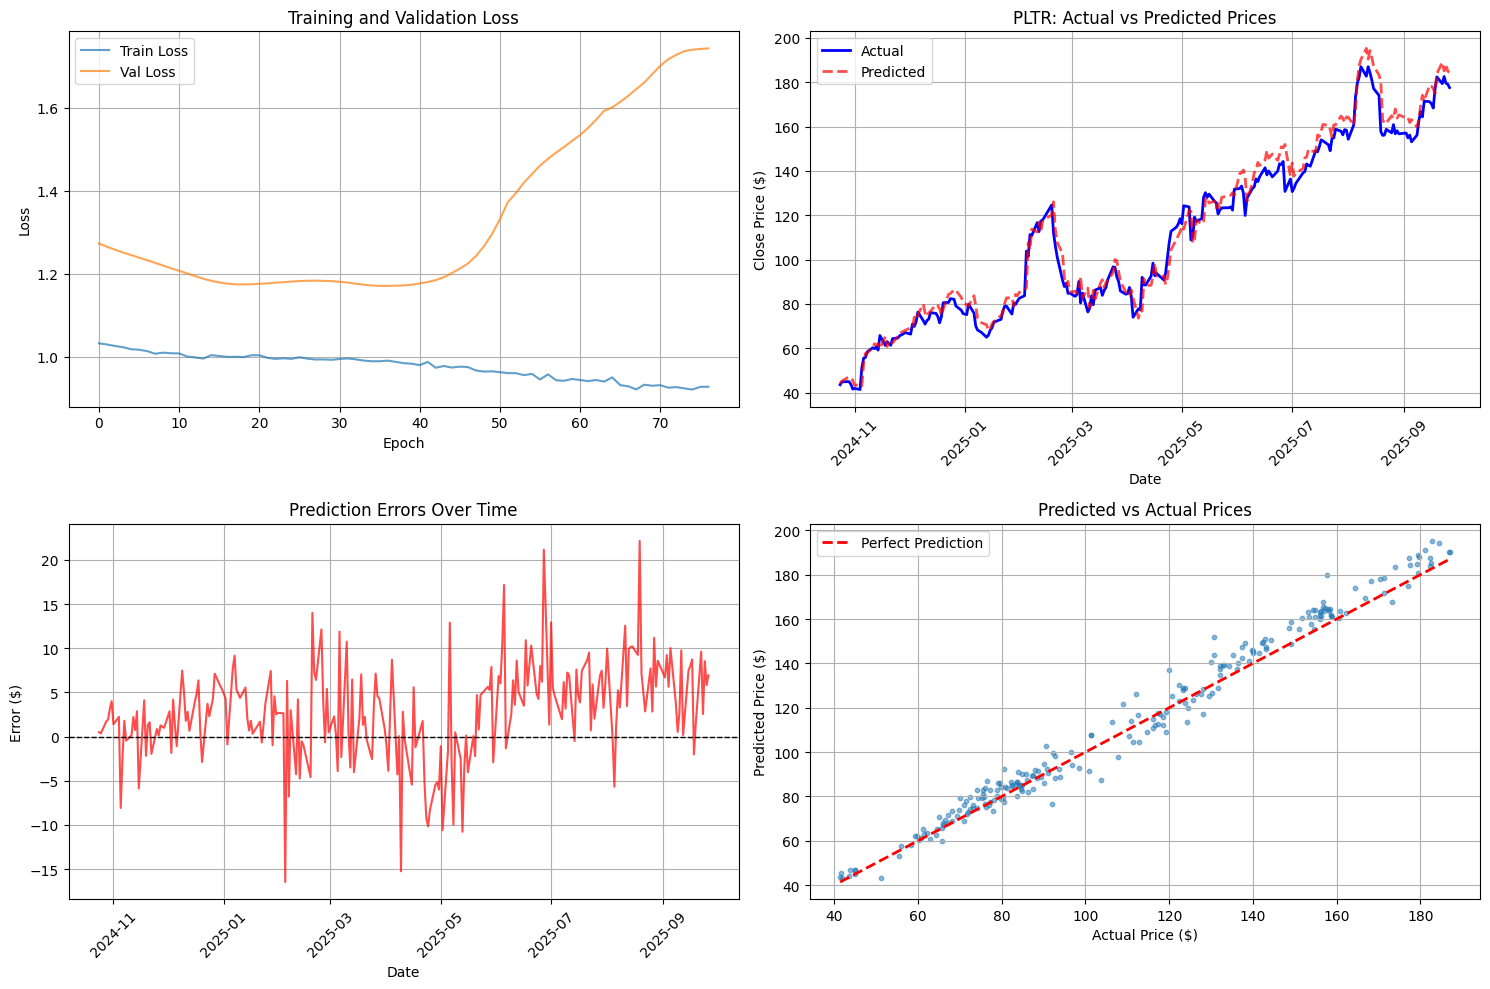


Making future prediction...
Current price: $177.57
Predicted return: +3.04%
Predicted next close price: $182.97
Predicted change: $+5.40

Model saved as PLTR_balanced_lstm.pth
Training complete!


In [6]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pickle
import yfinance as yf
import talib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Fetch latest data for the ticker
ticker = 'PLTR'
start_date = '2010-01-01'
end_date = '2025-09-30'

print(f"Downloading {ticker} data from {start_date} to {end_date}...")
df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)

print(f"Downloaded data shape: {df.shape}")

if df.empty:
    raise ValueError("No data downloaded. Check ticker symbol and date range.")

# Flatten MultiIndex columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Balanced technical indicators - not too many
print("Computing technical indicators...")
close_prices = np.array(df['Close'].values, dtype=np.float64).flatten()
high_prices = np.array(df['High'].values, dtype=np.float64).flatten()
low_prices = np.array(df['Low'].values, dtype=np.float64).flatten()
volume = np.array(df['Volume'].values, dtype=np.float64).flatten()

# Core momentum indicators
df['RSI_14'] = talib.RSI(close_prices, timeperiod=14)
macd, macds, macdh = talib.MACD(close_prices, fastperiod=12, slowperiod=26, signalperiod=9)
df['MACD'] = macd
df['MACD_Signal'] = macds
df['MACD_Hist'] = macdh

# Volatility
df['ATR'] = talib.ATR(high_prices, low_prices, close_prices, timeperiod=14)

# Trend indicators
df['SMA_20'] = talib.SMA(close_prices, timeperiod=20)
df['SMA_50'] = talib.SMA(close_prices, timeperiod=50)
df['EMA_12'] = talib.EMA(close_prices, timeperiod=12)

# Bollinger Bands
upper, middle, lower = talib.BBANDS(close_prices, timeperiod=20)
df['BB_Upper'] = upper
df['BB_Lower'] = lower
df['BB_Position'] = (close_prices - lower) / (upper - lower + 1e-8)  # Normalized position

# Volume
df['Volume_SMA'] = talib.SMA(volume, timeperiod=20)
df['Volume_Ratio'] = volume / (df['Volume_SMA'] + 1e-8)

# Price momentum
df['ROC_10'] = talib.ROC(close_prices, timeperiod=10)
df['MOM_10'] = talib.MOM(close_prices, timeperiod=10)

# Returns
df['Returns_1d'] = df['Close'].pct_change(1)
df['Returns_5d'] = df['Close'].pct_change(5)

# Volatility
df['Volatility_20d'] = df['Close'].rolling(window=20).std() / df['Close']

# Price relative to moving averages
df['Close_to_SMA20'] = (df['Close'] - df['SMA_20']) / df['SMA_20']
df['Close_to_SMA50'] = (df['Close'] - df['SMA_50']) / df['SMA_50']

# Drop rows with NaN
initial_len = len(df)
df = df.dropna()
print(f"Dropped {initial_len - len(df)} rows with NaN values")
print(f"Final dataset shape: {df.shape}")

if len(df) < 100:
    raise ValueError("Not enough data after removing NaN values")

# KEY CHANGE: Predict returns instead of absolute prices
# This helps the model generalize better to different price levels
df['Target_Return'] = df['Close'].pct_change(1).shift(-1)  # Next day's return
df = df.dropna()

# Feature set - balanced
features = [
    'Open', 'High', 'Low', 'Volume',
    'RSI_14', 'MACD', 'MACD_Hist', 'ATR',
    'SMA_20', 'SMA_50', 'EMA_12',
    'BB_Upper', 'BB_Lower', 'BB_Position',
    'Volume_Ratio', 'ROC_10', 'MOM_10',
    'Returns_1d', 'Returns_5d', 'Volatility_20d',
    'Close_to_SMA20', 'Close_to_SMA50'
]

target = 'Target_Return'  # Predicting returns now

print(f"Using {len(features)} features")
print(f"Target: {target}")

# Split data (80% train, 20% test)
train_size = int(len(df) * 0.8)
df_train = df.iloc[:train_size].copy()
df_test = df.iloc[train_size:].copy()

print(f"Training data: {len(df_train)} samples")
print(f"Test data: {len(df_test)} samples")

# Fit scalers ONLY on train data
X_train_raw = df_train[features].values
y_train_raw = df_train[target].values.reshape(-1, 1)

X_mean = X_train_raw.mean(axis=0)
X_std = X_train_raw.std(axis=0) + 1e-8
y_mean = y_train_raw.mean()
y_std = y_train_raw.std() + 1e-8

# Standardization (z-score) works better than min-max for returns
X_train_scaled = (X_train_raw - X_mean) / X_std
y_train_scaled = (y_train_raw - y_mean) / y_std

X_test_raw = df_test[features].values
y_test_raw = df_test[target].values.reshape(-1, 1)
X_test_scaled = (X_test_raw - X_mean) / X_std
y_test_scaled = (y_test_raw - y_mean) / y_std

# Create sequences
def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 10
print(f"Creating sequences with time_steps = {time_steps}")

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_steps)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, time_steps)

print(f"Training sequences shape: X={X_train_seq.shape}, y={y_train_seq.shape}")
print(f"Test sequences shape: X={X_test_seq.shape}, y={y_test_seq.shape}")

# Convert to PyTorch tensors
X_train = torch.tensor(X_train_seq, dtype=torch.float32)
y_train = torch.tensor(y_train_seq, dtype=torch.float32)
X_test = torch.tensor(X_test_seq, dtype=torch.float32)
y_test = torch.tensor(y_test_seq, dtype=torch.float32)

# Simpler but effective LSTM model
class BalancedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(BalancedLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size // 2, output_size)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])
        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out

# Moderate model parameters
input_size = X_train.shape[2]
hidden_size = 64  # Not too large
num_layers = 2
output_size = 1
dropout = 0.2

print(f"Model: input_size={input_size}, hidden_size={hidden_size}, num_layers={num_layers}")

model = BalancedLSTM(input_size, hidden_size, num_layers, output_size, dropout)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, 
                                                  patience=15, verbose=True)

# Early stopping
best_loss = float('inf')
patience_counter = 0
early_stop_patience = 40
best_model_state = None

# Training
epochs = 150
print(f"Training model for up to {epochs} epochs...")

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    
    train_losses.append(loss.item())
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test)
        val_loss = criterion(val_outputs, y_test)
    
    val_losses.append(val_loss.item())
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_loss:
        best_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
    
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.6f}, Val Loss: {val_loss.item():.6f}')
    
    if patience_counter >= early_stop_patience:
        print(f'Early stopping at epoch {epoch+1}')
        model.load_state_dict(best_model_state)
        break

# Evaluate on test set
print("\nEvaluating model on test set...")
model.eval()
with torch.no_grad():
    predicted_returns_scaled = model(X_test)
    test_loss = criterion(predicted_returns_scaled, y_test)
    print(f'Test Loss: {test_loss.item():.6f}')

    # Inverse scale predictions
    predicted_returns = predicted_returns_scaled.numpy() * y_std + y_mean
    actual_returns = y_test.numpy() * y_std + y_mean
    
    # Convert returns back to prices for evaluation
    test_dates = df_test.index[time_steps:]
    close_prices_aligned = df_test['Close'].values[time_steps-1:-1]  # Starting prices for each prediction
    
    predicted_prices = close_prices_aligned * (1 + predicted_returns.flatten())
    actual_prices = df_test['Close'].values[time_steps:]
    
    # Calculate metrics on prices
    mse = np.mean((predicted_prices - actual_prices) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(predicted_prices - actual_prices))
    mape = np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100
    
    # Direction accuracy on returns
    direction_correct = np.sum(np.sign(predicted_returns) == np.sign(actual_returns))
    direction_accuracy = direction_correct / len(predicted_returns) * 100
    
    within_1pct = np.sum(np.abs((predicted_prices - actual_prices) / actual_prices) <= 0.01) / len(predicted_prices) * 100
    within_3pct = np.sum(np.abs((predicted_prices - actual_prices) / actual_prices) <= 0.03) / len(predicted_prices) * 100
    within_5pct = np.sum(np.abs((predicted_prices - actual_prices) / actual_prices) <= 0.05) / len(predicted_prices) * 100
    
    correlation = np.corrcoef(predicted_prices, actual_prices)[0, 1]
    
    print(f'\n=== COMPREHENSIVE TEST METRICS ===')
    print(f'Root Mean Squared Error (RMSE): ${rmse:.2f}')
    print(f'Mean Absolute Error (MAE): ${mae:.2f}')
    print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')
    print(f'Direction Accuracy: {direction_accuracy:.1f}%')
    print(f'Correlation Coefficient: {correlation:.4f}')
    print(f'Predictions within 1%: {within_1pct:.1f}%')
    print(f'Predictions within 3%: {within_3pct:.1f}%')
    print(f'Predictions within 5%: {within_5pct:.1f}%')
    
    # Last 15 predictions
    print(f'\n=== LAST 15 PREDICTIONS ===')
    start_idx = max(0, len(predicted_prices) - 15)
    for i in range(start_idx, len(predicted_prices)):
        date_str = test_dates[i].strftime("%Y-%m-%d")
        error = predicted_prices[i] - actual_prices[i]
        error_pct = (error / actual_prices[i]) * 100
        pred_return = predicted_returns[i][0] * 100
        actual_return = actual_returns[i][0] * 100
        print(f'{date_str}: Predicted ${predicted_prices[i]:.2f} ({pred_return:+.2f}%), '
              f'Actual ${actual_prices[i]:.2f} ({actual_return:+.2f}%), Error ${error:+.2f} ({error_pct:+.1f}%)')

# Plot results
plt.figure(figsize=(15, 10))

# Training and validation loss
plt.subplot(2, 2, 1)
plt.plot(train_losses, label='Train Loss', alpha=0.7)
plt.plot(val_losses, label='Val Loss', alpha=0.7)
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Predictions vs Actual
plt.subplot(2, 2, 2)
plt.plot(test_dates, actual_prices, label='Actual', color='blue', linewidth=2)
plt.plot(test_dates, predicted_prices, label='Predicted', color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.title(f'{ticker}: Actual vs Predicted Prices')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

# Prediction errors
plt.subplot(2, 2, 3)
errors = predicted_prices - actual_prices
plt.plot(test_dates, errors, color='red', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Prediction Errors Over Time')
plt.xlabel('Date')
plt.ylabel('Error ($)')
plt.grid(True)
plt.xticks(rotation=45)

# Scatter plot - predicted vs actual
plt.subplot(2, 2, 4)
plt.scatter(actual_prices, predicted_prices, alpha=0.5, s=10)
plt.plot([actual_prices.min(), actual_prices.max()], 
         [actual_prices.min(), actual_prices.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Predicted vs Actual Prices')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Future prediction
print("\nMaking future prediction...")
X_full_scaled = (df[features].values - X_mean) / X_std
last_sequence = X_full_scaled[-time_steps:].reshape(1, time_steps, input_size)
last_sequence = torch.tensor(last_sequence, dtype=torch.float32)

with torch.no_grad():
    future_return_scaled = model(last_sequence)
    future_return = future_return_scaled.item() * y_std + y_mean
    
    current_price = float(df['Close'].iloc[-1])
    future_pred = current_price * (1 + future_return)
    price_change = future_pred - current_price
    price_change_pct = future_return * 100
    
    print(f'Current price: ${current_price:.2f}')
    print(f'Predicted return: {price_change_pct:+.2f}%')
    print(f'Predicted next close price: ${future_pred:.2f}')
    print(f'Predicted change: ${price_change:+.2f}')

# Save model
model_filename = f'{ticker}_balanced_lstm.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {
        'input_size': input_size,
        'hidden_size': hidden_size,
        'num_layers': num_layers,
        'output_size': output_size,
        'dropout': dropout
    },
    'features': features,
    'ticker': ticker,
    'time_steps': time_steps
}, model_filename)

scalers = {
    'X_mean': X_mean, 'X_std': X_std,
    'y_mean': y_mean, 'y_std': y_std,
    'features': features, 'ticker': ticker,
    'time_steps': time_steps
}
with open(f'{ticker}_balanced_scalers.pkl', 'wb') as f:
    pickle.dump(scalers, f)

print(f"\nModel saved as {model_filename}")
print("Training complete!")

[*********************100%***********************]  1 of 1 completed


Downloaded data shape: (3959, 5)
Computing technical indicators...
Dropped 49 rows with NaN values
Final dataset shape: (3910, 25)
Using 22 features
Target: Target_Return
Training data: 3127 samples
Test data: 782 samples
Creating sequences with time_steps = 10
Training sequences shape: X=(3117, 10, 22), y=(3117, 1)
Test sequences shape: X=(772, 10, 22), y=(772, 1)
Model: input_size=22, hidden_size=64, num_layers=2
Training model for up to 150 epochs...
Epoch [20/150], Train Loss: 1.001299, Val Loss: 0.977818
Epoch [40/150], Train Loss: 0.997483, Val Loss: 0.980650
Early stopping at epoch 55

Evaluating model on test set...
Test Loss: 0.985079

=== COMPREHENSIVE TEST METRICS ===
Root Mean Squared Error (RMSE): $3.32
Mean Absolute Error (MAE): $2.30
Mean Absolute Percentage Error (MAPE): 1.22%
Direction Accuracy: 49.4%
Correlation Coefficient: 0.9947
Predictions within 1%: 57.0%
Predictions within 3%: 92.4%
Predictions within 5%: 98.4%

=== LAST 15 PREDICTIONS ===
2025-09-08: Predicted 

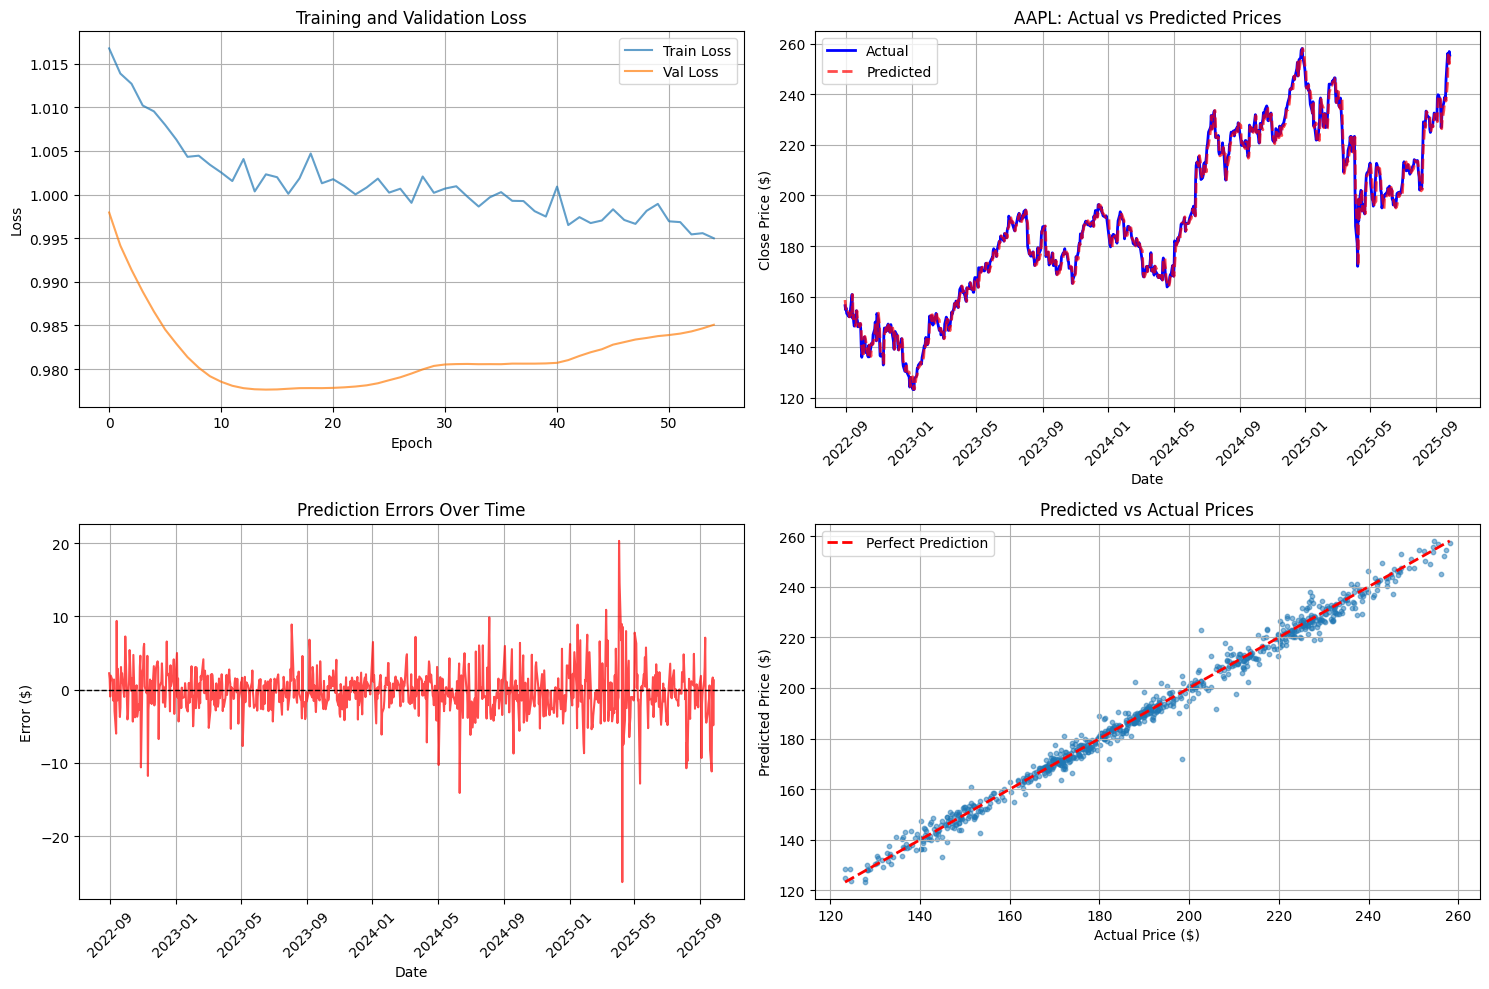


Making future prediction...
Current price: $255.46
Predicted return: -0.00%
Predicted next close price: $255.45
Predicted change: $-0.01

Model saved as Try_AAPL_balanced_lstm.pth
Training complete!


In [17]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pickle
import yfinance as yf
import talib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Fetch latest data for the ticker
ticker = 'AAPL'
start_date = '2010-01-01'
end_date = '2025-09-30'

print(f"Downloading {ticker} data from {start_date} to {end_date}...")
df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)

print(f"Downloaded data shape: {df.shape}")

if df.empty:
    raise ValueError("No data downloaded. Check ticker symbol and date range.")

# Flatten MultiIndex columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Balanced technical indicators - not too many
print("Computing technical indicators...")
close_prices = np.array(df['Close'].values, dtype=np.float64).flatten()
high_prices = np.array(df['High'].values, dtype=np.float64).flatten()
low_prices = np.array(df['Low'].values, dtype=np.float64).flatten()
volume = np.array(df['Volume'].values, dtype=np.float64).flatten()

# Core momentum indicators
df['RSI_14'] = talib.RSI(close_prices, timeperiod=14)
macd, macds, macdh = talib.MACD(close_prices, fastperiod=12, slowperiod=26, signalperiod=9)
df['MACD'] = macd
df['MACD_Signal'] = macds
df['MACD_Hist'] = macdh

# Volatility
df['ATR'] = talib.ATR(high_prices, low_prices, close_prices, timeperiod=14)

# Trend indicators
df['SMA_20'] = talib.SMA(close_prices, timeperiod=20)
df['SMA_50'] = talib.SMA(close_prices, timeperiod=50)
df['EMA_12'] = talib.EMA(close_prices, timeperiod=12)

# Bollinger Bands
upper, middle, lower = talib.BBANDS(close_prices, timeperiod=20)
df['BB_Upper'] = upper
df['BB_Lower'] = lower
df['BB_Position'] = (close_prices - lower) / (upper - lower + 1e-8)  # Normalized position

# Volume
df['Volume_SMA'] = talib.SMA(volume, timeperiod=20)
df['Volume_Ratio'] = volume / (df['Volume_SMA'] + 1e-8)

# Price momentum
df['ROC_10'] = talib.ROC(close_prices, timeperiod=10)
df['MOM_10'] = talib.MOM(close_prices, timeperiod=10)

# Returns
df['Returns_1d'] = df['Close'].pct_change(1)
df['Returns_5d'] = df['Close'].pct_change(5)

# Volatility
df['Volatility_20d'] = df['Close'].rolling(window=20).std() / df['Close']

# Price relative to moving averages
df['Close_to_SMA20'] = (df['Close'] - df['SMA_20']) / df['SMA_20']
df['Close_to_SMA50'] = (df['Close'] - df['SMA_50']) / df['SMA_50']

# Drop rows with NaN
initial_len = len(df)
df = df.dropna()
print(f"Dropped {initial_len - len(df)} rows with NaN values")
print(f"Final dataset shape: {df.shape}")

if len(df) < 100:
    raise ValueError("Not enough data after removing NaN values")

# KEY CHANGE: Predict returns instead of absolute prices
# This helps the model generalize better to different price levels
df['Target_Return'] = df['Close'].pct_change(1).shift(-1)  # Next day's return
df = df.dropna()

# Feature set - balanced
features = [
    'Open', 'High', 'Low', 'Volume',
    'RSI_14', 'MACD', 'MACD_Hist', 'ATR',
    'SMA_20', 'SMA_50', 'EMA_12',
    'BB_Upper', 'BB_Lower', 'BB_Position',
    'Volume_Ratio', 'ROC_10', 'MOM_10',
    'Returns_1d', 'Returns_5d', 'Volatility_20d',
    'Close_to_SMA20', 'Close_to_SMA50'
]

target = 'Target_Return'  # Predicting returns now

print(f"Using {len(features)} features")
print(f"Target: {target}")

# Split data (80% train, 20% test)
train_size = int(len(df) * 0.8)
df_train = df.iloc[:train_size].copy()
df_test = df.iloc[train_size:].copy()

print(f"Training data: {len(df_train)} samples")
print(f"Test data: {len(df_test)} samples")

# Fit scalers ONLY on train data
X_train_raw = df_train[features].values
y_train_raw = df_train[target].values.reshape(-1, 1)

X_mean = X_train_raw.mean(axis=0)
X_std = X_train_raw.std(axis=0) + 1e-8
y_mean = y_train_raw.mean()
y_std = y_train_raw.std() + 1e-8

# Standardization (z-score) works better than min-max for returns
X_train_scaled = (X_train_raw - X_mean) / X_std
y_train_scaled = (y_train_raw - y_mean) / y_std

X_test_raw = df_test[features].values
y_test_raw = df_test[target].values.reshape(-1, 1)
X_test_scaled = (X_test_raw - X_mean) / X_std
y_test_scaled = (y_test_raw - y_mean) / y_std

# Create sequences
def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 10
print(f"Creating sequences with time_steps = {time_steps}")

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_steps)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, time_steps)

print(f"Training sequences shape: X={X_train_seq.shape}, y={y_train_seq.shape}")
print(f"Test sequences shape: X={X_test_seq.shape}, y={y_test_seq.shape}")

# Convert to PyTorch tensors
X_train = torch.tensor(X_train_seq, dtype=torch.float32)
y_train = torch.tensor(y_train_seq, dtype=torch.float32)
X_test = torch.tensor(X_test_seq, dtype=torch.float32)
y_test = torch.tensor(y_test_seq, dtype=torch.float32)

# Simpler but effective LSTM model
class BalancedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(BalancedLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size // 2, output_size)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])
        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out

# Moderate model parameters
input_size = X_train.shape[2]
hidden_size = 64  # Not too large
num_layers = 2
output_size = 1
dropout = 0.2

print(f"Model: input_size={input_size}, hidden_size={hidden_size}, num_layers={num_layers}")

model = BalancedLSTM(input_size, hidden_size, num_layers, output_size, dropout)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, 
                                                  patience=15, verbose=True)

# Early stopping
best_loss = float('inf')
patience_counter = 0
early_stop_patience = 40
best_model_state = None

# Training
epochs = 150
print(f"Training model for up to {epochs} epochs...")

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    
    train_losses.append(loss.item())
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test)
        val_loss = criterion(val_outputs, y_test)
    
    val_losses.append(val_loss.item())
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_loss:
        best_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
    
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.6f}, Val Loss: {val_loss.item():.6f}')
    
    if patience_counter >= early_stop_patience:
        print(f'Early stopping at epoch {epoch+1}')
        model.load_state_dict(best_model_state)
        break

# Evaluate on test set
print("\nEvaluating model on test set...")
model.eval()
with torch.no_grad():
    predicted_returns_scaled = model(X_test)
    test_loss = criterion(predicted_returns_scaled, y_test)
    print(f'Test Loss: {test_loss.item():.6f}')

    # Inverse scale predictions
    predicted_returns = predicted_returns_scaled.numpy() * y_std + y_mean
    actual_returns = y_test.numpy() * y_std + y_mean
    
    # Convert returns back to prices for evaluation
    test_dates = df_test.index[time_steps:]
    close_prices_aligned = df_test['Close'].values[time_steps-1:-1]  # Starting prices for each prediction
    
    predicted_prices = close_prices_aligned * (1 + predicted_returns.flatten())
    actual_prices = df_test['Close'].values[time_steps:]
    
    # Calculate metrics on prices
    mse = np.mean((predicted_prices - actual_prices) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(predicted_prices - actual_prices))
    mape = np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100
    
    # Direction accuracy on returns
    direction_correct = np.sum(np.sign(predicted_returns) == np.sign(actual_returns))
    direction_accuracy = direction_correct / len(predicted_returns) * 100
    
    within_1pct = np.sum(np.abs((predicted_prices - actual_prices) / actual_prices) <= 0.01) / len(predicted_prices) * 100
    within_3pct = np.sum(np.abs((predicted_prices - actual_prices) / actual_prices) <= 0.03) / len(predicted_prices) * 100
    within_5pct = np.sum(np.abs((predicted_prices - actual_prices) / actual_prices) <= 0.05) / len(predicted_prices) * 100
    
    correlation = np.corrcoef(predicted_prices, actual_prices)[0, 1]
    
    print(f'\n=== COMPREHENSIVE TEST METRICS ===')
    print(f'Root Mean Squared Error (RMSE): ${rmse:.2f}')
    print(f'Mean Absolute Error (MAE): ${mae:.2f}')
    print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')
    print(f'Direction Accuracy: {direction_accuracy:.1f}%')
    print(f'Correlation Coefficient: {correlation:.4f}')
    print(f'Predictions within 1%: {within_1pct:.1f}%')
    print(f'Predictions within 3%: {within_3pct:.1f}%')
    print(f'Predictions within 5%: {within_5pct:.1f}%')
    
    # Last 15 predictions
    print(f'\n=== LAST 15 PREDICTIONS ===')
    start_idx = max(0, len(predicted_prices) - 15)
    for i in range(start_idx, len(predicted_prices)):
        date_str = test_dates[i].strftime("%Y-%m-%d")
        error = predicted_prices[i] - actual_prices[i]
        error_pct = (error / actual_prices[i]) * 100
        pred_return = predicted_returns[i][0] * 100
        actual_return = actual_returns[i][0] * 100
        print(f'{date_str}: Predicted ${predicted_prices[i]:.2f} ({pred_return:+.2f}%), '
              f'Actual ${actual_prices[i]:.2f} ({actual_return:+.2f}%), Error ${error:+.2f} ({error_pct:+.1f}%)')

# Plot results
plt.figure(figsize=(15, 10))

# Training and validation loss
plt.subplot(2, 2, 1)
plt.plot(train_losses, label='Train Loss', alpha=0.7)
plt.plot(val_losses, label='Val Loss', alpha=0.7)
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Predictions vs Actual
plt.subplot(2, 2, 2)
plt.plot(test_dates, actual_prices, label='Actual', color='blue', linewidth=2)
plt.plot(test_dates, predicted_prices, label='Predicted', color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.title(f'{ticker}: Actual vs Predicted Prices')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

# Prediction errors
plt.subplot(2, 2, 3)
errors = predicted_prices - actual_prices
plt.plot(test_dates, errors, color='red', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Prediction Errors Over Time')
plt.xlabel('Date')
plt.ylabel('Error ($)')
plt.grid(True)
plt.xticks(rotation=45)

# Scatter plot - predicted vs actual
plt.subplot(2, 2, 4)
plt.scatter(actual_prices, predicted_prices, alpha=0.5, s=10)
plt.plot([actual_prices.min(), actual_prices.max()], 
         [actual_prices.min(), actual_prices.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Predicted vs Actual Prices')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Future prediction
print("\nMaking future prediction...")
X_full_scaled = (df[features].values - X_mean) / X_std
last_sequence = X_full_scaled[-time_steps:].reshape(1, time_steps, input_size)
last_sequence = torch.tensor(last_sequence, dtype=torch.float32)

with torch.no_grad():
    future_return_scaled = model(last_sequence)
    future_return = future_return_scaled.item() * y_std + y_mean
    
    current_price = float(df['Close'].iloc[-1])
    future_pred = current_price * (1 + future_return)
    price_change = future_pred - current_price
    price_change_pct = future_return * 100
    
    print(f'Current price: ${current_price:.2f}')
    print(f'Predicted return: {price_change_pct:+.2f}%')
    print(f'Predicted next close price: ${future_pred:.2f}')
    print(f'Predicted change: ${price_change:+.2f}')

# Save model
model_filename = f'Try_{ticker}_balanced_lstm.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {
        'input_size': input_size,
        'hidden_size': hidden_size,
        'num_layers': num_layers,
        'output_size': output_size,
        'dropout': dropout
    },
    'features': features,
    'ticker': ticker,
    'time_steps': time_steps
}, model_filename)

scalers = {
    'X_mean': X_mean, 'X_std': X_std,
    'y_mean': y_mean, 'y_std': y_std,
    'features': features, 'ticker': ticker,
    'time_steps': time_steps
}
with open(f'{ticker}_balanced_scalers.pkl', 'wb') as f:
    pickle.dump(scalers, f)

print(f"\nModel saved as {model_filename}")
print("Training complete!")

In [7]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pickle
import yfinance as yf
import talib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Fetch latest data for the ticker
ticker = 'CRWV'
start_date = '2010-01-01'
end_date = '2025-09-30'

print(f"Downloading {ticker} data from {start_date} to {end_date}...")
df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)

print(f"Downloaded data shape: {df.shape}")

if df.empty:
    raise ValueError("No data downloaded. Check ticker symbol and date range.")

# Flatten MultiIndex columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Balanced technical indicators - not too many
print("Computing technical indicators...")
close_prices = np.array(df['Close'].values, dtype=np.float64).flatten()
high_prices = np.array(df['High'].values, dtype=np.float64).flatten()
low_prices = np.array(df['Low'].values, dtype=np.float64).flatten()
volume = np.array(df['Volume'].values, dtype=np.float64).flatten()

# Core momentum indicators
df['RSI_14'] = talib.RSI(close_prices, timeperiod=14)
macd, macds, macdh = talib.MACD(close_prices, fastperiod=12, slowperiod=26, signalperiod=9)
df['MACD'] = macd
df['MACD_Signal'] = macds
df['MACD_Hist'] = macdh

# Volatility
df['ATR'] = talib.ATR(high_prices, low_prices, close_prices, timeperiod=14)

# Trend indicators
df['SMA_20'] = talib.SMA(close_prices, timeperiod=20)
df['SMA_50'] = talib.SMA(close_prices, timeperiod=50)
df['EMA_12'] = talib.EMA(close_prices, timeperiod=12)

# Bollinger Bands
upper, middle, lower = talib.BBANDS(close_prices, timeperiod=20)
df['BB_Upper'] = upper
df['BB_Lower'] = lower
df['BB_Position'] = (close_prices - lower) / (upper - lower + 1e-8)  # Normalized position

# Volume
df['Volume_SMA'] = talib.SMA(volume, timeperiod=20)
df['Volume_Ratio'] = volume / (df['Volume_SMA'] + 1e-8)

# Price momentum
df['ROC_10'] = talib.ROC(close_prices, timeperiod=10)
df['MOM_10'] = talib.MOM(close_prices, timeperiod=10)

# Returns
df['Returns_1d'] = df['Close'].pct_change(1)
df['Returns_5d'] = df['Close'].pct_change(5)

# Volatility
df['Volatility_20d'] = df['Close'].rolling(window=20).std() / df['Close']

# Price relative to moving averages
df['Close_to_SMA20'] = (df['Close'] - df['SMA_20']) / df['SMA_20']
df['Close_to_SMA50'] = (df['Close'] - df['SMA_50']) / df['SMA_50']

# Drop rows with NaN
initial_len = len(df)
df = df.dropna()
print(f"Dropped {initial_len - len(df)} rows with NaN values")
print(f"Final dataset shape: {df.shape}")

if len(df) < 100:
    raise ValueError("Not enough data after removing NaN values")

# KEY CHANGE: Predict returns instead of absolute prices
# This helps the model generalize better to different price levels
df['Target_Return'] = df['Close'].pct_change(1).shift(-1)  # Next day's return
df = df.dropna()

# Feature set - balanced
features = [
    'Open', 'High', 'Low', 'Volume',
    'RSI_14', 'MACD', 'MACD_Hist', 'ATR',
    'SMA_20', 'SMA_50', 'EMA_12',
    'BB_Upper', 'BB_Lower', 'BB_Position',
    'Volume_Ratio', 'ROC_10', 'MOM_10',
    'Returns_1d', 'Returns_5d', 'Volatility_20d',
    'Close_to_SMA20', 'Close_to_SMA50'
]

target = 'Target_Return'  # Predicting returns now

print(f"Using {len(features)} features")
print(f"Target: {target}")

# Split data (80% train, 20% test)
train_size = int(len(df) * 0.8)
df_train = df.iloc[:train_size].copy()
df_test = df.iloc[train_size:].copy()

print(f"Training data: {len(df_train)} samples")
print(f"Test data: {len(df_test)} samples")

# Fit scalers ONLY on train data
X_train_raw = df_train[features].values
y_train_raw = df_train[target].values.reshape(-1, 1)

X_mean = X_train_raw.mean(axis=0)
X_std = X_train_raw.std(axis=0) + 1e-8
y_mean = y_train_raw.mean()
y_std = y_train_raw.std() + 1e-8

# Standardization (z-score) works better than min-max for returns
X_train_scaled = (X_train_raw - X_mean) / X_std
y_train_scaled = (y_train_raw - y_mean) / y_std

X_test_raw = df_test[features].values
y_test_raw = df_test[target].values.reshape(-1, 1)
X_test_scaled = (X_test_raw - X_mean) / X_std
y_test_scaled = (y_test_raw - y_mean) / y_std

# Create sequences
def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 10
print(f"Creating sequences with time_steps = {time_steps}")

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_steps)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, time_steps)

print(f"Training sequences shape: X={X_train_seq.shape}, y={y_train_seq.shape}")
print(f"Test sequences shape: X={X_test_seq.shape}, y={y_test_seq.shape}")

# Convert to PyTorch tensors
X_train = torch.tensor(X_train_seq, dtype=torch.float32)
y_train = torch.tensor(y_train_seq, dtype=torch.float32)
X_test = torch.tensor(X_test_seq, dtype=torch.float32)
y_test = torch.tensor(y_test_seq, dtype=torch.float32)

# Simpler but effective LSTM model
class BalancedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(BalancedLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size // 2, output_size)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])
        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out

# Moderate model parameters
input_size = X_train.shape[2]
hidden_size = 64  # Not too large
num_layers = 2
output_size = 1
dropout = 0.2

print(f"Model: input_size={input_size}, hidden_size={hidden_size}, num_layers={num_layers}")

model = BalancedLSTM(input_size, hidden_size, num_layers, output_size, dropout)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, 
                                                  patience=15, verbose=True)

# Early stopping
best_loss = float('inf')
patience_counter = 0
early_stop_patience = 40
best_model_state = None

# Training
epochs = 150
print(f"Training model for up to {epochs} epochs...")

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    
    train_losses.append(loss.item())
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test)
        val_loss = criterion(val_outputs, y_test)
    
    val_losses.append(val_loss.item())
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_loss:
        best_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
    
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.6f}, Val Loss: {val_loss.item():.6f}')
    
    if patience_counter >= early_stop_patience:
        print(f'Early stopping at epoch {epoch+1}')
        model.load_state_dict(best_model_state)
        break

# Evaluate on test set
print("\nEvaluating model on test set...")
model.eval()
with torch.no_grad():
    predicted_returns_scaled = model(X_test)
    test_loss = criterion(predicted_returns_scaled, y_test)
    print(f'Test Loss: {test_loss.item():.6f}')

    # Inverse scale predictions
    predicted_returns = predicted_returns_scaled.numpy() * y_std + y_mean
    actual_returns = y_test.numpy() * y_std + y_mean
    
    # Convert returns back to prices for evaluation
    test_dates = df_test.index[time_steps:]
    close_prices_aligned = df_test['Close'].values[time_steps-1:-1]  # Starting prices for each prediction
    
    predicted_prices = close_prices_aligned * (1 + predicted_returns.flatten())
    actual_prices = df_test['Close'].values[time_steps:]
    
    # Calculate metrics on prices
    mse = np.mean((predicted_prices - actual_prices) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(predicted_prices - actual_prices))
    mape = np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100
    
    # Direction accuracy on returns
    direction_correct = np.sum(np.sign(predicted_returns) == np.sign(actual_returns))
    direction_accuracy = direction_correct / len(predicted_returns) * 100
    
    within_1pct = np.sum(np.abs((predicted_prices - actual_prices) / actual_prices) <= 0.01) / len(predicted_prices) * 100
    within_3pct = np.sum(np.abs((predicted_prices - actual_prices) / actual_prices) <= 0.03) / len(predicted_prices) * 100
    within_5pct = np.sum(np.abs((predicted_prices - actual_prices) / actual_prices) <= 0.05) / len(predicted_prices) * 100
    
    correlation = np.corrcoef(predicted_prices, actual_prices)[0, 1]
    
    print(f'\n=== COMPREHENSIVE TEST METRICS ===')
    print(f'Root Mean Squared Error (RMSE): ${rmse:.2f}')
    print(f'Mean Absolute Error (MAE): ${mae:.2f}')
    print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')
    print(f'Direction Accuracy: {direction_accuracy:.1f}%')
    print(f'Correlation Coefficient: {correlation:.4f}')
    print(f'Predictions within 1%: {within_1pct:.1f}%')
    print(f'Predictions within 3%: {within_3pct:.1f}%')
    print(f'Predictions within 5%: {within_5pct:.1f}%')
    
    # Last 15 predictions
    print(f'\n=== LAST 15 PREDICTIONS ===')
    start_idx = max(0, len(predicted_prices) - 15)
    for i in range(start_idx, len(predicted_prices)):
        date_str = test_dates[i].strftime("%Y-%m-%d")
        error = predicted_prices[i] - actual_prices[i]
        error_pct = (error / actual_prices[i]) * 100
        pred_return = predicted_returns[i][0] * 100
        actual_return = actual_returns[i][0] * 100
        print(f'{date_str}: Predicted ${predicted_prices[i]:.2f} ({pred_return:+.2f}%), '
              f'Actual ${actual_prices[i]:.2f} ({actual_return:+.2f}%), Error ${error:+.2f} ({error_pct:+.1f}%)')

# Plot results
plt.figure(figsize=(15, 10))

# Training and validation loss
plt.subplot(2, 2, 1)
plt.plot(train_losses, label='Train Loss', alpha=0.7)
plt.plot(val_losses, label='Val Loss', alpha=0.7)
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Predictions vs Actual
plt.subplot(2, 2, 2)
plt.plot(test_dates, actual_prices, label='Actual', color='blue', linewidth=2)
plt.plot(test_dates, predicted_prices, label='Predicted', color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.title(f'{ticker}: Actual vs Predicted Prices')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

# Prediction errors
plt.subplot(2, 2, 3)
errors = predicted_prices - actual_prices
plt.plot(test_dates, errors, color='red', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Prediction Errors Over Time')
plt.xlabel('Date')
plt.ylabel('Error ($)')
plt.grid(True)
plt.xticks(rotation=45)

# Scatter plot - predicted vs actual
plt.subplot(2, 2, 4)
plt.scatter(actual_prices, predicted_prices, alpha=0.5, s=10)
plt.plot([actual_prices.min(), actual_prices.max()], 
         [actual_prices.min(), actual_prices.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Predicted vs Actual Prices')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Future prediction
print("\nMaking future prediction...")
X_full_scaled = (df[features].values - X_mean) / X_std
last_sequence = X_full_scaled[-time_steps:].reshape(1, time_steps, input_size)
last_sequence = torch.tensor(last_sequence, dtype=torch.float32)

with torch.no_grad():
    future_return_scaled = model(last_sequence)
    future_return = future_return_scaled.item() * y_std + y_mean
    
    current_price = float(df['Close'].iloc[-1])
    future_pred = current_price * (1 + future_return)
    price_change = future_pred - current_price
    price_change_pct = future_return * 100
    
    print(f'Current price: ${current_price:.2f}')
    print(f'Predicted return: {price_change_pct:+.2f}%')
    print(f'Predicted next close price: ${future_pred:.2f}')
    print(f'Predicted change: ${price_change:+.2f}')

# Save model
model_filename = f'Try_{ticker}_balanced_lstm.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {
        'input_size': input_size,
        'hidden_size': hidden_size,
        'num_layers': num_layers,
        'output_size': output_size,
        'dropout': dropout
    },
    'features': features,
    'ticker': ticker,
    'time_steps': time_steps
}, model_filename)

scalers = {
    'X_mean': X_mean, 'X_std': X_std,
    'y_mean': y_mean, 'y_std': y_std,
    'features': features, 'ticker': ticker,
    'time_steps': time_steps
}
with open(f'{ticker}_balanced_scalers.pkl', 'wb') as f:
    pickle.dump(scalers, f)

print(f"\nModel saved as {model_filename}")
print("Training complete!")

[*********************100%***********************]  1 of 1 completed

Downloaded data shape: (127, 5)
Computing technical indicators...
Dropped 49 rows with NaN values
Final dataset shape: (78, 25)


ValueError: Not enough data after removing NaN values

[*********************100%***********************]  1 of 1 completed


Downloaded data shape: (3959, 5)
Computing technical indicators...
Dropped 49 rows with NaN values
Final dataset shape: (3910, 25)
Using 22 features
Target: Target_Return
Training data: 3127 samples
Test data: 782 samples
Creating sequences with time_steps = 10
Training sequences shape: X=(3117, 10, 22), y=(3117, 1)
Test sequences shape: X=(772, 10, 22), y=(772, 1)
Model: input_size=22, hidden_size=64, num_layers=2
Training model for up to 150 epochs...
Epoch [20/150], Train Loss: 1.001394, Val Loss: 1.393869
Epoch [40/150], Train Loss: 0.995880, Val Loss: 1.405506
Early stopping at epoch 44

Evaluating model on test set...
Test Loss: 1.404227

=== COMPREHENSIVE TEST METRICS ===
Root Mean Squared Error (RMSE): $2.91
Mean Absolute Error (MAE): $2.06
Mean Absolute Percentage Error (MAPE): 1.43%
Direction Accuracy: 47.3%
Correlation Coefficient: 0.9968
Predictions within 1%: 46.8%
Predictions within 3%: 91.2%
Predictions within 5%: 97.5%

=== LAST 15 PREDICTIONS ===
2025-09-08: Predicted 

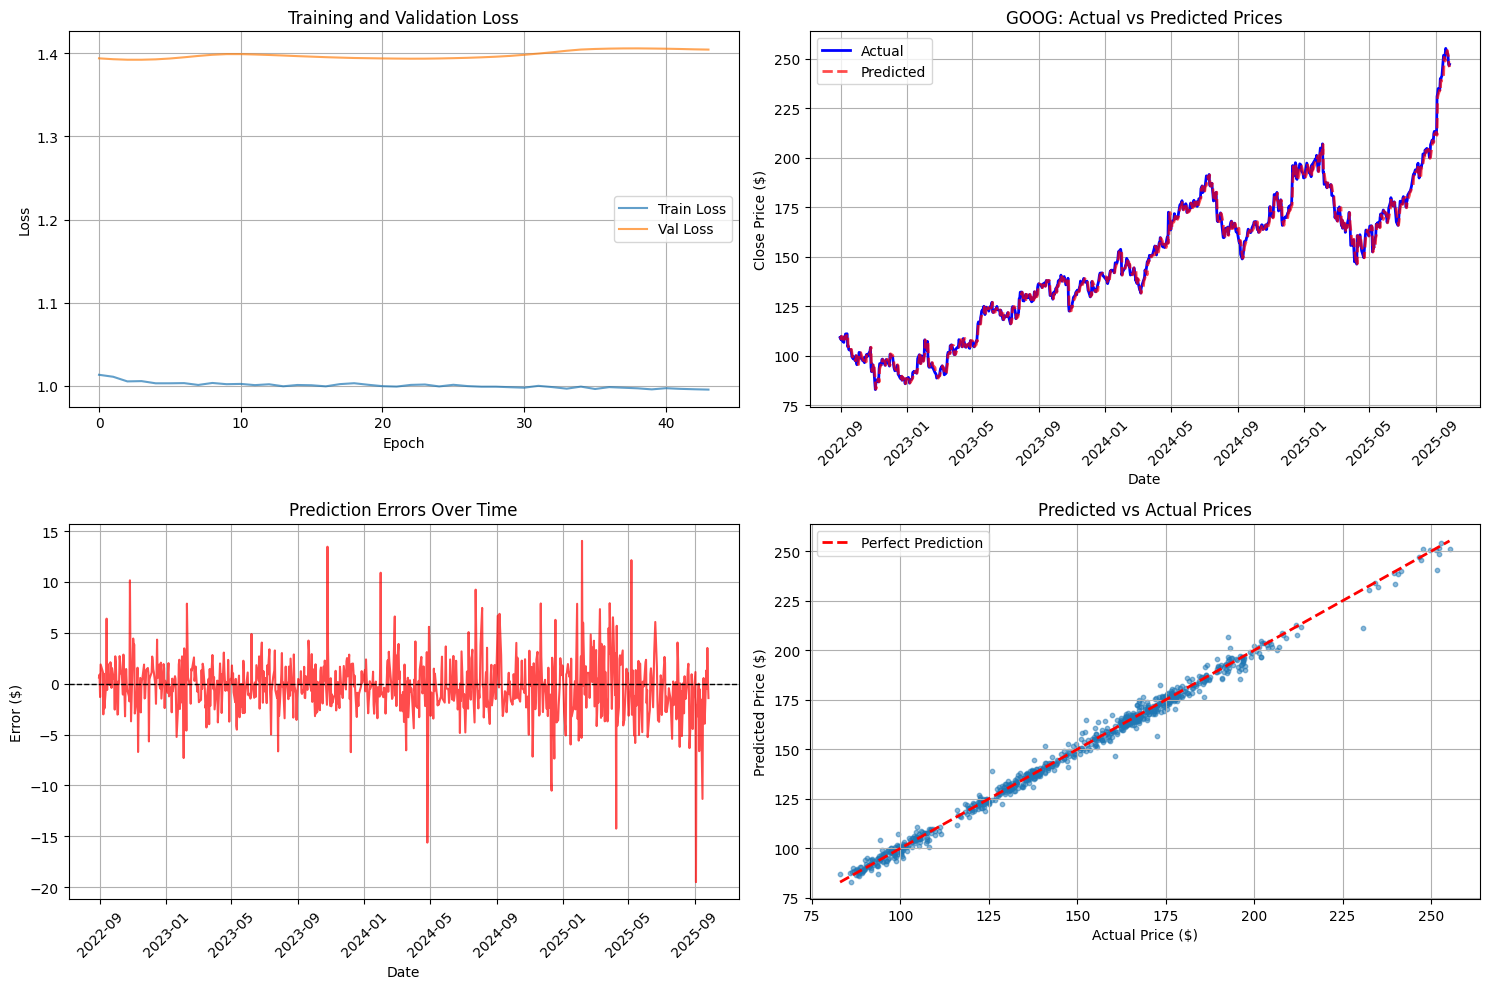


Making future prediction...
Current price: $247.18
Predicted return: -0.29%
Predicted next close price: $246.45
Predicted change: $-0.73

Model saved as Try_GOOG_balanced_lstm.pth
Training complete!


In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pickle
import yfinance as yf
import talib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Fetch latest data for the ticker
ticker = 'GOOG'
start_date = '2010-01-01'
end_date = '2025-09-30'

print(f"Downloading {ticker} data from {start_date} to {end_date}...")
df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)

print(f"Downloaded data shape: {df.shape}")

if df.empty:
    raise ValueError("No data downloaded. Check ticker symbol and date range.")

# Flatten MultiIndex columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Balanced technical indicators - not too many
print("Computing technical indicators...")
close_prices = np.array(df['Close'].values, dtype=np.float64).flatten()
high_prices = np.array(df['High'].values, dtype=np.float64).flatten()
low_prices = np.array(df['Low'].values, dtype=np.float64).flatten()
volume = np.array(df['Volume'].values, dtype=np.float64).flatten()

# Core momentum indicators
df['RSI_14'] = talib.RSI(close_prices, timeperiod=14)
macd, macds, macdh = talib.MACD(close_prices, fastperiod=12, slowperiod=26, signalperiod=9)
df['MACD'] = macd
df['MACD_Signal'] = macds
df['MACD_Hist'] = macdh

# Volatility
df['ATR'] = talib.ATR(high_prices, low_prices, close_prices, timeperiod=14)

# Trend indicators
df['SMA_20'] = talib.SMA(close_prices, timeperiod=20)
df['SMA_50'] = talib.SMA(close_prices, timeperiod=50)
df['EMA_12'] = talib.EMA(close_prices, timeperiod=12)

# Bollinger Bands
upper, middle, lower = talib.BBANDS(close_prices, timeperiod=20)
df['BB_Upper'] = upper
df['BB_Lower'] = lower
df['BB_Position'] = (close_prices - lower) / (upper - lower + 1e-8)  # Normalized position

# Volume
df['Volume_SMA'] = talib.SMA(volume, timeperiod=20)
df['Volume_Ratio'] = volume / (df['Volume_SMA'] + 1e-8)

# Price momentum
df['ROC_10'] = talib.ROC(close_prices, timeperiod=10)
df['MOM_10'] = talib.MOM(close_prices, timeperiod=10)

# Returns
df['Returns_1d'] = df['Close'].pct_change(1)
df['Returns_5d'] = df['Close'].pct_change(5)

# Volatility
df['Volatility_20d'] = df['Close'].rolling(window=20).std() / df['Close']

# Price relative to moving averages
df['Close_to_SMA20'] = (df['Close'] - df['SMA_20']) / df['SMA_20']
df['Close_to_SMA50'] = (df['Close'] - df['SMA_50']) / df['SMA_50']

# Drop rows with NaN
initial_len = len(df)
df = df.dropna()
print(f"Dropped {initial_len - len(df)} rows with NaN values")
print(f"Final dataset shape: {df.shape}")

if len(df) < 100:
    raise ValueError("Not enough data after removing NaN values")

# KEY CHANGE: Predict returns instead of absolute prices
# This helps the model generalize better to different price levels
df['Target_Return'] = df['Close'].pct_change(1).shift(-1)  # Next day's return
df = df.dropna()

# Feature set - balanced
features = [
    'Open', 'High', 'Low', 'Volume',
    'RSI_14', 'MACD', 'MACD_Hist', 'ATR',
    'SMA_20', 'SMA_50', 'EMA_12',
    'BB_Upper', 'BB_Lower', 'BB_Position',
    'Volume_Ratio', 'ROC_10', 'MOM_10',
    'Returns_1d', 'Returns_5d', 'Volatility_20d',
    'Close_to_SMA20', 'Close_to_SMA50'
]

target = 'Target_Return'  # Predicting returns now

print(f"Using {len(features)} features")
print(f"Target: {target}")

# Split data (80% train, 20% test)
train_size = int(len(df) * 0.8)
df_train = df.iloc[:train_size].copy()
df_test = df.iloc[train_size:].copy()

print(f"Training data: {len(df_train)} samples")
print(f"Test data: {len(df_test)} samples")

# Fit scalers ONLY on train data
X_train_raw = df_train[features].values
y_train_raw = df_train[target].values.reshape(-1, 1)

X_mean = X_train_raw.mean(axis=0)
X_std = X_train_raw.std(axis=0) + 1e-8
y_mean = y_train_raw.mean()
y_std = y_train_raw.std() + 1e-8

# Standardization (z-score) works better than min-max for returns
X_train_scaled = (X_train_raw - X_mean) / X_std
y_train_scaled = (y_train_raw - y_mean) / y_std

X_test_raw = df_test[features].values
y_test_raw = df_test[target].values.reshape(-1, 1)
X_test_scaled = (X_test_raw - X_mean) / X_std
y_test_scaled = (y_test_raw - y_mean) / y_std

# Create sequences
def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 10
print(f"Creating sequences with time_steps = {time_steps}")

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_steps)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, time_steps)

print(f"Training sequences shape: X={X_train_seq.shape}, y={y_train_seq.shape}")
print(f"Test sequences shape: X={X_test_seq.shape}, y={y_test_seq.shape}")

# Convert to PyTorch tensors
X_train = torch.tensor(X_train_seq, dtype=torch.float32)
y_train = torch.tensor(y_train_seq, dtype=torch.float32)
X_test = torch.tensor(X_test_seq, dtype=torch.float32)
y_test = torch.tensor(y_test_seq, dtype=torch.float32)

# Simpler but effective LSTM model
class BalancedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(BalancedLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size // 2, output_size)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])
        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out

# Moderate model parameters
input_size = X_train.shape[2]
hidden_size = 64  # Not too large
num_layers = 2
output_size = 1
dropout = 0.2

print(f"Model: input_size={input_size}, hidden_size={hidden_size}, num_layers={num_layers}")

model = BalancedLSTM(input_size, hidden_size, num_layers, output_size, dropout)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, 
                                                  patience=15, verbose=True)

# Early stopping
best_loss = float('inf')
patience_counter = 0
early_stop_patience = 40
best_model_state = None

# Training
epochs = 150
print(f"Training model for up to {epochs} epochs...")

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    
    train_losses.append(loss.item())
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test)
        val_loss = criterion(val_outputs, y_test)
    
    val_losses.append(val_loss.item())
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_loss:
        best_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
    
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.6f}, Val Loss: {val_loss.item():.6f}')
    
    if patience_counter >= early_stop_patience:
        print(f'Early stopping at epoch {epoch+1}')
        model.load_state_dict(best_model_state)
        break

# Evaluate on test set
print("\nEvaluating model on test set...")
model.eval()
with torch.no_grad():
    predicted_returns_scaled = model(X_test)
    test_loss = criterion(predicted_returns_scaled, y_test)
    print(f'Test Loss: {test_loss.item():.6f}')

    # Inverse scale predictions
    predicted_returns = predicted_returns_scaled.numpy() * y_std + y_mean
    actual_returns = y_test.numpy() * y_std + y_mean
    
    # Convert returns back to prices for evaluation
    test_dates = df_test.index[time_steps:]
    close_prices_aligned = df_test['Close'].values[time_steps-1:-1]  # Starting prices for each prediction
    
    predicted_prices = close_prices_aligned * (1 + predicted_returns.flatten())
    actual_prices = df_test['Close'].values[time_steps:]
    
    # Calculate metrics on prices
    mse = np.mean((predicted_prices - actual_prices) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(predicted_prices - actual_prices))
    mape = np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100
    
    # Direction accuracy on returns
    direction_correct = np.sum(np.sign(predicted_returns) == np.sign(actual_returns))
    direction_accuracy = direction_correct / len(predicted_returns) * 100
    
    within_1pct = np.sum(np.abs((predicted_prices - actual_prices) / actual_prices) <= 0.01) / len(predicted_prices) * 100
    within_3pct = np.sum(np.abs((predicted_prices - actual_prices) / actual_prices) <= 0.03) / len(predicted_prices) * 100
    within_5pct = np.sum(np.abs((predicted_prices - actual_prices) / actual_prices) <= 0.05) / len(predicted_prices) * 100
    
    correlation = np.corrcoef(predicted_prices, actual_prices)[0, 1]
    
    print(f'\n=== COMPREHENSIVE TEST METRICS ===')
    print(f'Root Mean Squared Error (RMSE): ${rmse:.2f}')
    print(f'Mean Absolute Error (MAE): ${mae:.2f}')
    print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')
    print(f'Direction Accuracy: {direction_accuracy:.1f}%')
    print(f'Correlation Coefficient: {correlation:.4f}')
    print(f'Predictions within 1%: {within_1pct:.1f}%')
    print(f'Predictions within 3%: {within_3pct:.1f}%')
    print(f'Predictions within 5%: {within_5pct:.1f}%')
    
    # Last 15 predictions
    print(f'\n=== LAST 15 PREDICTIONS ===')
    start_idx = max(0, len(predicted_prices) - 15)
    for i in range(start_idx, len(predicted_prices)):
        date_str = test_dates[i].strftime("%Y-%m-%d")
        error = predicted_prices[i] - actual_prices[i]
        error_pct = (error / actual_prices[i]) * 100
        pred_return = predicted_returns[i][0] * 100
        actual_return = actual_returns[i][0] * 100
        print(f'{date_str}: Predicted ${predicted_prices[i]:.2f} ({pred_return:+.2f}%), '
              f'Actual ${actual_prices[i]:.2f} ({actual_return:+.2f}%), Error ${error:+.2f} ({error_pct:+.1f}%)')

# Plot results
plt.figure(figsize=(15, 10))

# Training and validation loss
plt.subplot(2, 2, 1)
plt.plot(train_losses, label='Train Loss', alpha=0.7)
plt.plot(val_losses, label='Val Loss', alpha=0.7)
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Predictions vs Actual
plt.subplot(2, 2, 2)
plt.plot(test_dates, actual_prices, label='Actual', color='blue', linewidth=2)
plt.plot(test_dates, predicted_prices, label='Predicted', color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.title(f'{ticker}: Actual vs Predicted Prices')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

# Prediction errors
plt.subplot(2, 2, 3)
errors = predicted_prices - actual_prices
plt.plot(test_dates, errors, color='red', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Prediction Errors Over Time')
plt.xlabel('Date')
plt.ylabel('Error ($)')
plt.grid(True)
plt.xticks(rotation=45)

# Scatter plot - predicted vs actual
plt.subplot(2, 2, 4)
plt.scatter(actual_prices, predicted_prices, alpha=0.5, s=10)
plt.plot([actual_prices.min(), actual_prices.max()], 
         [actual_prices.min(), actual_prices.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Predicted vs Actual Prices')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Future prediction
print("\nMaking future prediction...")
X_full_scaled = (df[features].values - X_mean) / X_std
last_sequence = X_full_scaled[-time_steps:].reshape(1, time_steps, input_size)
last_sequence = torch.tensor(last_sequence, dtype=torch.float32)

with torch.no_grad():
    future_return_scaled = model(last_sequence)
    future_return = future_return_scaled.item() * y_std + y_mean
    
    current_price = float(df['Close'].iloc[-1])
    future_pred = current_price * (1 + future_return)
    price_change = future_pred - current_price
    price_change_pct = future_return * 100
    
    print(f'Current price: ${current_price:.2f}')
    print(f'Predicted return: {price_change_pct:+.2f}%')
    print(f'Predicted next close price: ${future_pred:.2f}')
    print(f'Predicted change: ${price_change:+.2f}')

# Save model
model_filename = f'Try_{ticker}_balanced_lstm.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {
        'input_size': input_size,
        'hidden_size': hidden_size,
        'num_layers': num_layers,
        'output_size': output_size,
        'dropout': dropout
    },
    'features': features,
    'ticker': ticker,
    'time_steps': time_steps
}, model_filename)

scalers = {
    'X_mean': X_mean, 'X_std': X_std,
    'y_mean': y_mean, 'y_std': y_std,
    'features': features, 'ticker': ticker,
    'time_steps': time_steps
}
with open(f'{ticker}_balanced_scalers.pkl', 'wb') as f:
    pickle.dump(scalers, f)

print(f"\nModel saved as {model_filename}")
print("Training complete!")

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pickle
import yfinance as yf
import talib
import matplotlib.pyplot as plt
import warnings
import os
import zipfile
from datetime import datetime

warnings.filterwarnings('ignore')

# Create external_utils folder if it doesn't exist
os.makedirs('external_utils', exist_ok=True)

# List of tickers to train
tickers = [
    'INSM', 'ALNY', 'TEVA', 'IQV', 'A', 'TMO', 'HCA', 'CAH', 'NTRA', 'GILD',
    'OKLO', 'EBR', 'NRG', 'AES', 'CEG', 'SBS', 'VST', 'NEE', 'SRE', 'ES',
    'HL', 'CDE', 'B', 'CX', 'GFI', 'ALB', 'KGC', 'AU', 'NEM', 'SCCO',
    'WELL', 'CBRE', 'PLD', 'OHI', 'HST', 'AGNC', 'VTR', 'NLY', 'SPG', 'WPC',
    'EL', 'BTI', 'BG', 'DLTR', 'ADM', 'PFGC', 'EDU', 'MNST', 'PEP', 'USFD',
    'CCJ', 'VLO', 'FTI', 'HAL', 'CVE', 'MPC', 'BKR', 'PSX', 'BP', 'EC',
    'STX', 'MU', 'AMD', 'LRCX', 'GLW', 'INTC', 'NET', 'AVGO', 'DDOG', 'APH',
    'LVS', 'TSLA', 'GM', 'CCL', 'CUK', 'VIK', 'AMZN', 'BABA', 'EXPE', 'WSM',
    'NBIS', 'SATS', 'WBD', 'LUMN', 'APP', 'ROKU', 'GOOGL', 'GOOG', 'RDDT', 'BILI'
]


# Common parameters
start_date = '2010-01-01'
end_date = datetime.now().strftime('%Y-%m-%d')  # Current date
time_steps = 10
train_split = 0.8

# Model parameters
hidden_size = 64
num_layers = 2
output_size = 1
dropout = 0.2
learning_rate = 0.001
weight_decay = 1e-5
epochs = 150
early_stop_patience = 40

# LSTM Model Definition
class BalancedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(BalancedLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size // 2, output_size)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])
        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out

def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

def train_model_for_ticker(ticker):
    print(f"\n{'='*80}")
    print(f"TRAINING MODEL FOR {ticker}")
    print(f"{'='*80}\n")
    
    try:
        # Fetch data
        print(f"Downloading {ticker} data from {start_date} to {end_date}...")
        df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)
        
        print(f"Downloaded data shape: {df.shape}")
        
        if df.empty:
            raise ValueError("No data downloaded. Check ticker symbol and date range.")
        
        # Flatten MultiIndex columns if present
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        
        # Compute technical indicators
        print("Computing technical indicators...")
        close_prices = np.array(df['Close'].values, dtype=np.float64).flatten()
        high_prices = np.array(df['High'].values, dtype=np.float64).flatten()
        low_prices = np.array(df['Low'].values, dtype=np.float64).flatten()
        volume = np.array(df['Volume'].values, dtype=np.float64).flatten()
        
        # Core momentum indicators
        df['RSI_14'] = talib.RSI(close_prices, timeperiod=14)
        macd, macds, macdh = talib.MACD(close_prices, fastperiod=12, slowperiod=26, signalperiod=9)
        df['MACD'] = macd
        df['MACD_Signal'] = macds
        df['MACD_Hist'] = macdh
        
        # Volatility
        df['ATR'] = talib.ATR(high_prices, low_prices, close_prices, timeperiod=14)
        
        # Trend indicators
        df['SMA_20'] = talib.SMA(close_prices, timeperiod=20)
        df['SMA_50'] = talib.SMA(close_prices, timeperiod=50)
        df['EMA_12'] = talib.EMA(close_prices, timeperiod=12)
        
        # Bollinger Bands
        upper, middle, lower = talib.BBANDS(close_prices, timeperiod=20)
        df['BB_Upper'] = upper
        df['BB_Lower'] = lower
        df['BB_Position'] = (close_prices - lower) / (upper - lower + 1e-8)
        
        # Volume
        df['Volume_SMA'] = talib.SMA(volume, timeperiod=20)
        df['Volume_Ratio'] = volume / (df['Volume_SMA'] + 1e-8)
        
        # Price momentum
        df['ROC_10'] = talib.ROC(close_prices, timeperiod=10)
        df['MOM_10'] = talib.MOM(close_prices, timeperiod=10)
        
        # Returns
        df['Returns_1d'] = df['Close'].pct_change(1)
        df['Returns_5d'] = df['Close'].pct_change(5)
        
        # Volatility
        df['Volatility_20d'] = df['Close'].rolling(window=20).std() / df['Close']
        
        # Price relative to moving averages
        df['Close_to_SMA20'] = (df['Close'] - df['SMA_20']) / df['SMA_20']
        df['Close_to_SMA50'] = (df['Close'] - df['SMA_50']) / df['SMA_50']
        
        # Drop rows with NaN
        initial_len = len(df)
        df = df.dropna()
        print(f"Dropped {initial_len - len(df)} rows with NaN values")
        print(f"Final dataset shape: {df.shape}")
        
        if len(df) < 100:
            raise ValueError("Not enough data after removing NaN values")
        
        # Predict returns instead of absolute prices
        df['Target_Return'] = df['Close'].pct_change(1).shift(-1)
        df = df.dropna()
        
        # Feature set
        features = [
            'Open', 'High', 'Low', 'Volume',
            'RSI_14', 'MACD', 'MACD_Hist', 'ATR',
            'SMA_20', 'SMA_50', 'EMA_12',
            'BB_Upper', 'BB_Lower', 'BB_Position',
            'Volume_Ratio', 'ROC_10', 'MOM_10',
            'Returns_1d', 'Returns_5d', 'Volatility_20d',
            'Close_to_SMA20', 'Close_to_SMA50'
        ]
        
        target = 'Target_Return'
        
        print(f"Using {len(features)} features")
        print(f"Target: {target}")
        
        # Split data
        train_size = int(len(df) * train_split)
        df_train = df.iloc[:train_size].copy()
        df_test = df.iloc[train_size:].copy()
        
        print(f"Training data: {len(df_train)} samples")
        print(f"Test data: {len(df_test)} samples")
        
        # Fit scalers on train data
        X_train_raw = df_train[features].values
        y_train_raw = df_train[target].values.reshape(-1, 1)
        
        X_mean = X_train_raw.mean(axis=0)
        X_std = X_train_raw.std(axis=0) + 1e-8
        y_mean = y_train_raw.mean()
        y_std = y_train_raw.std() + 1e-8
        
        X_train_scaled = (X_train_raw - X_mean) / X_std
        y_train_scaled = (y_train_raw - y_mean) / y_std
        
        X_test_raw = df_test[features].values
        y_test_raw = df_test[target].values.reshape(-1, 1)
        X_test_scaled = (X_test_raw - X_mean) / X_std
        y_test_scaled = (y_test_raw - y_mean) / y_std
        
        # Create sequences
        print(f"Creating sequences with time_steps = {time_steps}")
        X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_steps)
        X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, time_steps)
        
        print(f"Training sequences shape: X={X_train_seq.shape}, y={y_train_seq.shape}")
        print(f"Test sequences shape: X={X_test_seq.shape}, y={y_test_seq.shape}")
        
        # Convert to PyTorch tensors
        X_train = torch.tensor(X_train_seq, dtype=torch.float32)
        y_train = torch.tensor(y_train_seq, dtype=torch.float32)
        X_test = torch.tensor(X_test_seq, dtype=torch.float32)
        y_test = torch.tensor(y_test_seq, dtype=torch.float32)
        
        # Initialize model
        input_size = X_train.shape[2]
        print(f"Model: input_size={input_size}, hidden_size={hidden_size}, num_layers={num_layers}")
        
        model = BalancedLSTM(input_size, hidden_size, num_layers, output_size, dropout)
        
        # Loss and optimizer
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, 
                                                          patience=15, verbose=True)
        
        # Early stopping
        best_loss = float('inf')
        patience_counter = 0
        best_model_state = None
        
        # Training
        print(f"Training model for up to {epochs} epochs...")
        train_losses = []
        val_losses = []
        
        for epoch in range(epochs):
            model.train()
            outputs = model(X_train)
            loss = criterion(outputs, y_train)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_losses.append(loss.item())
            
            # Validation
            model.eval()
            with torch.no_grad():
                val_outputs = model(X_test)
                val_loss = criterion(val_outputs, y_test)
            
            val_losses.append(val_loss.item())
            scheduler.step(val_loss)
            
            # Early stopping
            if val_loss < best_loss:
                best_loss = val_loss
                patience_counter = 0
                best_model_state = model.state_dict().copy()
            else:
                patience_counter += 1
            
            if (epoch + 1) % 20 == 0:
                print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.6f}, Val Loss: {val_loss.item():.6f}')
            
            if patience_counter >= early_stop_patience:
                print(f'Early stopping at epoch {epoch+1}')
                model.load_state_dict(best_model_state)
                break
        
        # Evaluate on test set
        print("\nEvaluating model on test set...")
        model.eval()
        with torch.no_grad():
            predicted_returns_scaled = model(X_test)
            test_loss = criterion(predicted_returns_scaled, y_test)
            print(f'Test Loss: {test_loss.item():.6f}')
            
            # Inverse scale predictions
            predicted_returns = predicted_returns_scaled.numpy() * y_std + y_mean
            actual_returns = y_test.numpy() * y_std + y_mean
            
            # Convert returns back to prices for evaluation
            test_dates = df_test.index[time_steps:]
            close_prices_aligned = df_test['Close'].values[time_steps-1:-1]
            
            predicted_prices = close_prices_aligned * (1 + predicted_returns.flatten())
            actual_prices = df_test['Close'].values[time_steps:]
            
            # Calculate metrics
            mse = np.mean((predicted_prices - actual_prices) ** 2)
            rmse = np.sqrt(mse)
            mae = np.mean(np.abs(predicted_prices - actual_prices))
            mape = np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100
            
            direction_correct = np.sum(np.sign(predicted_returns) == np.sign(actual_returns))
            direction_accuracy = direction_correct / len(predicted_returns) * 100
            
            within_1pct = np.sum(np.abs((predicted_prices - actual_prices) / actual_prices) <= 0.01) / len(predicted_prices) * 100
            within_3pct = np.sum(np.abs((predicted_prices - actual_prices) / actual_prices) <= 0.03) / len(predicted_prices) * 100
            within_5pct = np.sum(np.abs((predicted_prices - actual_prices) / actual_prices) <= 0.05) / len(predicted_prices) * 100
            
            correlation = np.corrcoef(predicted_prices, actual_prices)[0, 1]
            
            print(f'\n=== COMPREHENSIVE TEST METRICS FOR {ticker} ===')
            print(f'Root Mean Squared Error (RMSE): ${rmse:.2f}')
            print(f'Mean Absolute Error (MAE): ${mae:.2f}')
            print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')
            print(f'Direction Accuracy: {direction_accuracy:.1f}%')
            print(f'Correlation Coefficient: {correlation:.4f}')
            print(f'Predictions within 1%: {within_1pct:.1f}%')
            print(f'Predictions within 3%: {within_3pct:.1f}%')
            print(f'Predictions within 5%: {within_5pct:.1f}%')
            
            # Last 15 predictions
            print(f'\n=== LAST 15 PREDICTIONS ===')
            start_idx = max(0, len(predicted_prices) - 15)
            for i in range(start_idx, len(predicted_prices)):
                date_str = test_dates[i].strftime("%Y-%m-%d")
                error = predicted_prices[i] - actual_prices[i]
                error_pct = (error / actual_prices[i]) * 100
                pred_return = predicted_returns[i][0] * 100
                actual_return = actual_returns[i][0] * 100
                print(f'{date_str}: Predicted ${predicted_prices[i]:.2f} ({pred_return:+.2f}%), '
                      f'Actual ${actual_prices[i]:.2f} ({actual_return:+.2f}%), Error ${error:+.2f} ({error_pct:+.1f}%)')
        
        # Future prediction
        print("\nMaking future prediction...")
        X_full_scaled = (df[features].values - X_mean) / X_std
        last_sequence = X_full_scaled[-time_steps:].reshape(1, time_steps, input_size)
        last_sequence = torch.tensor(last_sequence, dtype=torch.float32)
        
        with torch.no_grad():
            future_return_scaled = model(last_sequence)
            future_return = future_return_scaled.item() * y_std + y_mean
            
            current_price = float(df['Close'].iloc[-1])
            future_pred = current_price * (1 + future_return)
            price_change = future_pred - current_price
            price_change_pct = future_return * 100
            
            print(f'Current price: ${current_price:.2f}')
            print(f'Predicted return: {price_change_pct:+.2f}%')
            print(f'Predicted next close price: ${future_pred:.2f}')
            print(f'Predicted change: ${price_change:+.2f}')
        
        # Save model in external_utils folder
        model_filename = f'external_utils/{ticker}_balanced_lstm.pth'
        torch.save({
            'model_state_dict': model.state_dict(),
            'model_config': {
                'input_size': input_size,
                'hidden_size': hidden_size,
                'num_layers': num_layers,
                'output_size': output_size,
                'dropout': dropout
            },
            'features': features,
            'ticker': ticker,
            'time_steps': time_steps
        }, model_filename)
        
        scalers = {
            'X_mean': X_mean, 'X_std': X_std,
            'y_mean': y_mean, 'y_std': y_std,
            'features': features, 'ticker': ticker,
            'time_steps': time_steps
        }
        scaler_filename = f'external_utils/{ticker}_balanced_scalers.pkl'
        with open(scaler_filename, 'wb') as f:
            pickle.dump(scalers, f)
        
        print(f"\nModel saved as {model_filename}")
        print(f"Scalers saved as {scaler_filename}")
        print(f"✓ Training complete for {ticker}!")
        
        return {
            'ticker': ticker,
            'success': True,
            'rmse': rmse,
            'mae': mae,
            'mape': mape,
            'direction_accuracy': direction_accuracy,
            'correlation': correlation
        }
        
    except Exception as e:
        print(f"\n✗ ERROR training model for {ticker}: {str(e)}")
        return {
            'ticker': ticker,
            'success': False,
            'error': str(e)
        }

# Main training loop
if __name__ == "__main__":
    print("="*80)
    print("MULTI-TICKER LSTM TRAINING PIPELINE")
    print("="*80)
    print(f"Tickers to train: {', '.join(tickers)}")
    print(f"Output folder: external_utils/")
    print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)
    
    results = []
    
    for i, ticker in enumerate(tickers, 1):
        print(f"\n[{i}/{len(tickers)}] Processing {ticker}...")
        result = train_model_for_ticker(ticker)
        results.append(result)
    
    # Summary
    print("\n" + "="*80)
    print("TRAINING SUMMARY")
    print("="*80)
    
    successful = [r for r in results if r['success']]
    failed = [r for r in results if not r['success']]
    
    print(f"\nSuccessfully trained: {len(successful)}/{len(tickers)} models")
    
    if successful:
        print("\n--- Successful Models ---")
        for r in successful:
            print(f"\n{r['ticker']}:")
            print(f"  RMSE: ${r['rmse']:.2f}")
            print(f"  MAE: ${r['mae']:.2f}")
            print(f"  MAPE: {r['mape']:.2f}%")
            print(f"  Direction Accuracy: {r['direction_accuracy']:.1f}%")
            print(f"  Correlation: {r['correlation']:.4f}")
    
    if failed:
        print("\n--- Failed Models ---")
        for r in failed:
            print(f"{r['ticker']}: {r['error']}")
    
    print(f"\nEnd time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"All files saved in: external_utils/")
    print("="*80)
    
    # Create zip file of external_utils folder contents (not the folder itself)
    print("\nCreating zip file for download...")
    zip_filename = 'external_utils.zip'
    
    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk('external_utils'):
            for file in files:
                file_path = os.path.join(root, file)
                # Add files directly to zip root (not inside external_utils folder)
                zipf.write(file_path, file)
                print(f"  Added: {file}")
    
    zip_size = os.path.getsize(zip_filename) / (1024 * 1024)  # Size in MB
    print(f"\n✓ Zip file created: {zip_filename} ({zip_size:.2f} MB)")
    print(f"You can download this file from Kaggle's output section!")
    print("="*80)

ModuleNotFoundError: No module named 'talib'

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pickle
import yfinance as yf
import talib
import matplotlib.pyplot as plt
import warnings
import os
import zipfile
from datetime import datetime

warnings.filterwarnings('ignore')

# Create external_utils folder if it doesn't exist
os.makedirs('external_utils', exist_ok=True)

# List of tickers to train
tickers = [
    'INSM', 'ALNY', 'TEVA', 'IQV', 'A', 'TMO', 'HCA', 'CAH', 'NTRA', 'GILD',
    'OKLO', 'EBR', 'NRG', 'AES', 'CEG', 'SBS', 'VST', 'NEE', 'SRE', 'ES',
    'HL', 'CDE', 'B', 'CX', 'GFI', 'ALB', 'KGC', 'AU', 'NEM', 'SCCO',
    'WELL', 'CBRE', 'PLD', 'OHI', 'HST', 'AGNC', 'VTR', 'NLY', 'SPG', 'WPC',
    'EL', 'BTI', 'BG', 'DLTR', 'ADM', 'PFGC', 'EDU', 'MNST', 'PEP', 'USFD',
    'CCJ', 'VLO', 'FTI', 'HAL', 'CVE', 'MPC', 'BKR', 'PSX', 'BP', 'EC',
    'STX', 'MU', 'AMD', 'LRCX', 'GLW', 'INTC', 'NET', 'AVGO', 'DDOG', 'APH',
    'LVS', 'TSLA', 'GM', 'CCL', 'CUK', 'VIK', 'AMZN', 'BABA', 'EXPE', 'WSM',
    'NBIS', 'SATS', 'WBD', 'LUMN', 'APP', 'ROKU', 'GOOGL', 'GOOG', 'RDDT', 'BILI'
]



# Common parameters
start_date = '2010-01-01'
end_date = datetime.now().strftime('%Y-%m-%d')  # Current date
time_steps = 10
train_split = 0.8

# Model parameters
hidden_size = 64
num_layers = 2
output_size = 1
dropout = 0.2
learning_rate = 0.001
weight_decay = 1e-5
epochs = 150
early_stop_patience = 40

# LSTM Model Definition
class BalancedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(BalancedLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size // 2, output_size)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])
        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out

def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

def train_model_for_ticker(ticker):
    print(f"\n{'='*80}")
    print(f"TRAINING MODEL FOR {ticker}")
    print(f"{'='*80}\n")
    
    try:
        # Fetch data
        print(f"Downloading {ticker} data from {start_date} to {end_date}...")
        df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)
        
        print(f"Downloaded data shape: {df.shape}")
        
        if df.empty:
            raise ValueError("No data downloaded. Check ticker symbol and date range.")
        
        # Flatten MultiIndex columns if present
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        
        # Compute technical indicators
        print("Computing technical indicators...")
        close_prices = np.array(df['Close'].values, dtype=np.float64).flatten()
        high_prices = np.array(df['High'].values, dtype=np.float64).flatten()
        low_prices = np.array(df['Low'].values, dtype=np.float64).flatten()
        volume = np.array(df['Volume'].values, dtype=np.float64).flatten()
        
        # Core momentum indicators
        df['RSI_14'] = talib.RSI(close_prices, timeperiod=14)
        macd, macds, macdh = talib.MACD(close_prices, fastperiod=12, slowperiod=26, signalperiod=9)
        df['MACD'] = macd
        df['MACD_Signal'] = macds
        df['MACD_Hist'] = macdh
        
        # Volatility
        df['ATR'] = talib.ATR(high_prices, low_prices, close_prices, timeperiod=14)
        
        # Trend indicators
        df['SMA_20'] = talib.SMA(close_prices, timeperiod=20)
        df['SMA_50'] = talib.SMA(close_prices, timeperiod=50)
        df['EMA_12'] = talib.EMA(close_prices, timeperiod=12)
        
        # Bollinger Bands
        upper, middle, lower = talib.BBANDS(close_prices, timeperiod=20)
        df['BB_Upper'] = upper
        df['BB_Lower'] = lower
        df['BB_Position'] = (close_prices - lower) / (upper - lower + 1e-8)
        
        # Volume
        df['Volume_SMA'] = talib.SMA(volume, timeperiod=20)
        df['Volume_Ratio'] = volume / (df['Volume_SMA'] + 1e-8)
        
        # Price momentum
        df['ROC_10'] = talib.ROC(close_prices, timeperiod=10)
        df['MOM_10'] = talib.MOM(close_prices, timeperiod=10)
        
        # Returns
        df['Returns_1d'] = df['Close'].pct_change(1)
        df['Returns_5d'] = df['Close'].pct_change(5)
        
        # Volatility
        df['Volatility_20d'] = df['Close'].rolling(window=20).std() / df['Close']
        
        # Price relative to moving averages
        df['Close_to_SMA20'] = (df['Close'] - df['SMA_20']) / df['SMA_20']
        df['Close_to_SMA50'] = (df['Close'] - df['SMA_50']) / df['SMA_50']
        
        # Drop rows with NaN
        initial_len = len(df)
        df = df.dropna()
        print(f"Dropped {initial_len - len(df)} rows with NaN values")
        print(f"Final dataset shape: {df.shape}")
        
        if len(df) < 100:
            raise ValueError("Not enough data after removing NaN values")
        
        # Predict returns instead of absolute prices
        df['Target_Return'] = df['Close'].pct_change(1).shift(-1)
        df = df.dropna()
        
        # Feature set
        features = [
            'Open', 'High', 'Low', 'Volume',
            'RSI_14', 'MACD', 'MACD_Hist', 'ATR',
            'SMA_20', 'SMA_50', 'EMA_12',
            'BB_Upper', 'BB_Lower', 'BB_Position',
            'Volume_Ratio', 'ROC_10', 'MOM_10',
            'Returns_1d', 'Returns_5d', 'Volatility_20d',
            'Close_to_SMA20', 'Close_to_SMA50'
        ]
        
        target = 'Target_Return'
        
        print(f"Using {len(features)} features")
        print(f"Target: {target}")
        
        # Split data
        train_size = int(len(df) * train_split)
        df_train = df.iloc[:train_size].copy()
        df_test = df.iloc[train_size:].copy()
        
        print(f"Training data: {len(df_train)} samples")
        print(f"Test data: {len(df_test)} samples")
        
        # Fit scalers on train data
        X_train_raw = df_train[features].values
        y_train_raw = df_train[target].values.reshape(-1, 1)
        
        X_mean = X_train_raw.mean(axis=0)
        X_std = X_train_raw.std(axis=0) + 1e-8
        y_mean = y_train_raw.mean()
        y_std = y_train_raw.std() + 1e-8
        
        X_train_scaled = (X_train_raw - X_mean) / X_std
        y_train_scaled = (y_train_raw - y_mean) / y_std
        
        X_test_raw = df_test[features].values
        y_test_raw = df_test[target].values.reshape(-1, 1)
        X_test_scaled = (X_test_raw - X_mean) / X_std
        y_test_scaled = (y_test_raw - y_mean) / y_std
        
        # Create sequences
        print(f"Creating sequences with time_steps = {time_steps}")
        X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_steps)
        X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, time_steps)
        
        print(f"Training sequences shape: X={X_train_seq.shape}, y={y_train_seq.shape}")
        print(f"Test sequences shape: X={X_test_seq.shape}, y={y_test_seq.shape}")
        
        # Convert to PyTorch tensors
        X_train = torch.tensor(X_train_seq, dtype=torch.float32)
        y_train = torch.tensor(y_train_seq, dtype=torch.float32)
        X_test = torch.tensor(X_test_seq, dtype=torch.float32)
        y_test = torch.tensor(y_test_seq, dtype=torch.float32)
        
        # Initialize model
        input_size = X_train.shape[2]
        print(f"Model: input_size={input_size}, hidden_size={hidden_size}, num_layers={num_layers}")
        
        model = BalancedLSTM(input_size, hidden_size, num_layers, output_size, dropout)
        
        # Loss and optimizer
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, 
                                                          patience=15, verbose=True)
        
        # Early stopping
        best_loss = float('inf')
        patience_counter = 0
        best_model_state = None
        
        # Training
        print(f"Training model for up to {epochs} epochs...")
        train_losses = []
        val_losses = []
        
        for epoch in range(epochs):
            model.train()
            outputs = model(X_train)
            loss = criterion(outputs, y_train)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_losses.append(loss.item())
            
            # Validation
            model.eval()
            with torch.no_grad():
                val_outputs = model(X_test)
                val_loss = criterion(val_outputs, y_test)
            
            val_losses.append(val_loss.item())
            scheduler.step(val_loss)
            
            # Early stopping
            if val_loss < best_loss:
                best_loss = val_loss
                patience_counter = 0
                best_model_state = model.state_dict().copy()
            else:
                patience_counter += 1
            
            if (epoch + 1) % 20 == 0:
                print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.6f}, Val Loss: {val_loss.item():.6f}')
            
            if patience_counter >= early_stop_patience:
                print(f'Early stopping at epoch {epoch+1}')
                model.load_state_dict(best_model_state)
                break
        
        # Evaluate on test set
        print("\nEvaluating model on test set...")
        model.eval()
        with torch.no_grad():
            predicted_returns_scaled = model(X_test)
            test_loss = criterion(predicted_returns_scaled, y_test)
            print(f'Test Loss: {test_loss.item():.6f}')
            
            # Inverse scale predictions
            predicted_returns = predicted_returns_scaled.numpy() * y_std + y_mean
            actual_returns = y_test.numpy() * y_std + y_mean
            
            # Convert returns back to prices for evaluation
            test_dates = df_test.index[time_steps:]
            close_prices_aligned = df_test['Close'].values[time_steps-1:-1]
            
            predicted_prices = close_prices_aligned * (1 + predicted_returns.flatten())
            actual_prices = df_test['Close'].values[time_steps:]
            
            # Calculate metrics
            mse = np.mean((predicted_prices - actual_prices) ** 2)
            rmse = np.sqrt(mse)
            mae = np.mean(np.abs(predicted_prices - actual_prices))
            mape = np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100
            
            direction_correct = np.sum(np.sign(predicted_returns) == np.sign(actual_returns))
            direction_accuracy = direction_correct / len(predicted_returns) * 100
            
            within_1pct = np.sum(np.abs((predicted_prices - actual_prices) / actual_prices) <= 0.01) / len(predicted_prices) * 100
            within_3pct = np.sum(np.abs((predicted_prices - actual_prices) / actual_prices) <= 0.03) / len(predicted_prices) * 100
            within_5pct = np.sum(np.abs((predicted_prices - actual_prices) / actual_prices) <= 0.05) / len(predicted_prices) * 100
            
            correlation = np.corrcoef(predicted_prices, actual_prices)[0, 1]
            
            print(f'\n=== COMPREHENSIVE TEST METRICS FOR {ticker} ===')
            print(f'Root Mean Squared Error (RMSE): ${rmse:.2f}')
            print(f'Mean Absolute Error (MAE): ${mae:.2f}')
            print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')
            print(f'Direction Accuracy: {direction_accuracy:.1f}%')
            print(f'Correlation Coefficient: {correlation:.4f}')
            print(f'Predictions within 1%: {within_1pct:.1f}%')
            print(f'Predictions within 3%: {within_3pct:.1f}%')
            print(f'Predictions within 5%: {within_5pct:.1f}%')
            
            # Last 15 predictions
            print(f'\n=== LAST 15 PREDICTIONS ===')
            start_idx = max(0, len(predicted_prices) - 15)
            for i in range(start_idx, len(predicted_prices)):
                date_str = test_dates[i].strftime("%Y-%m-%d")
                error = predicted_prices[i] - actual_prices[i]
                error_pct = (error / actual_prices[i]) * 100
                pred_return = predicted_returns[i][0] * 100
                actual_return = actual_returns[i][0] * 100
                print(f'{date_str}: Predicted ${predicted_prices[i]:.2f} ({pred_return:+.2f}%), '
                      f'Actual ${actual_prices[i]:.2f} ({actual_return:+.2f}%), Error ${error:+.2f} ({error_pct:+.1f}%)')
        
        # Future prediction
        print("\nMaking future prediction...")
        X_full_scaled = (df[features].values - X_mean) / X_std
        last_sequence = X_full_scaled[-time_steps:].reshape(1, time_steps, input_size)
        last_sequence = torch.tensor(last_sequence, dtype=torch.float32)
        
        with torch.no_grad():
            future_return_scaled = model(last_sequence)
            future_return = future_return_scaled.item() * y_std + y_mean
            
            current_price = float(df['Close'].iloc[-1])
            future_pred = current_price * (1 + future_return)
            price_change = future_pred - current_price
            price_change_pct = future_return * 100
            
            print(f'Current price: ${current_price:.2f}')
            print(f'Predicted return: {price_change_pct:+.2f}%')
            print(f'Predicted next close price: ${future_pred:.2f}')
            print(f'Predicted change: ${price_change:+.2f}')
        
        # Save model in external_utils folder
        model_filename = f'external_utils/{ticker}_balanced_lstm.pth'
        torch.save({
            'model_state_dict': model.state_dict(),
            'model_config': {
                'input_size': input_size,
                'hidden_size': hidden_size,
                'num_layers': num_layers,
                'output_size': output_size,
                'dropout': dropout
            },
            'features': features,
            'ticker': ticker,
            'time_steps': time_steps
        }, model_filename)
        
        scalers = {
            'X_mean': X_mean, 'X_std': X_std,
            'y_mean': y_mean, 'y_std': y_std,
            'features': features, 'ticker': ticker,
            'time_steps': time_steps
        }
        scaler_filename = f'external_utils/{ticker}_balanced_scalers.pkl'
        with open(scaler_filename, 'wb') as f:
            pickle.dump(scalers, f)
        
        print(f"\nModel saved as {model_filename}")
        print(f"Scalers saved as {scaler_filename}")
        print(f"✓ Training complete for {ticker}!")
        
        return {
            'ticker': ticker,
            'success': True,
            'rmse': rmse,
            'mae': mae,
            'mape': mape,
            'direction_accuracy': direction_accuracy,
            'correlation': correlation
        }
        
    except Exception as e:
        print(f"\n✗ ERROR training model for {ticker}: {str(e)}")
        return {
            'ticker': ticker,
            'success': False,
            'error': str(e)
        }

# Main training loop
if __name__ == "__main__":
    print("="*80)
    print("MULTI-TICKER LSTM TRAINING PIPELINE")
    print("="*80)
    print(f"Tickers to train: {', '.join(tickers)}")
    print(f"Output folder: external_utils/")
    print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)
    
    results = []
    
    for i, ticker in enumerate(tickers, 1):
        print(f"\n[{i}/{len(tickers)}] Processing {ticker}...")
        result = train_model_for_ticker(ticker)
        results.append(result)
    
    # Summary
    print("\n" + "="*80)
    print("TRAINING SUMMARY")
    print("="*80)
    
    successful = [r for r in results if r['success']]
    failed = [r for r in results if not r['success']]
    
    print(f"\nSuccessfully trained: {len(successful)}/{len(tickers)} models")
    
    if successful:
        print("\n--- Successful Models ---")
        for r in successful:
            print(f"\n{r['ticker']}:")
            print(f"  RMSE: ${r['rmse']:.2f}")
            print(f"  MAE: ${r['mae']:.2f}")
            print(f"  MAPE: {r['mape']:.2f}%")
            print(f"  Direction Accuracy: {r['direction_accuracy']:.1f}%")
            print(f"  Correlation: {r['correlation']:.4f}")
    
    if failed:
        print("\n--- Failed Models ---")
        for r in failed:
            print(f"{r['ticker']}: {r['error']}")
    
    print(f"\nEnd time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"All files saved in: external_utils/")
    print("="*80)
    
    # Create zip file of external_utils folder contents (not the folder itself)
    print("\nCreating zip file for download...")
    zip_filename = 'external_utils.zip'
    
    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk('external_utils'):
            for file in files:
                file_path = os.path.join(root, file)
                # Add files directly to zip root (not inside external_utils folder)
                zipf.write(file_path, file)
                print(f"  Added: {file}")
    
    zip_size = os.path.getsize(zip_filename) / (1024 * 1024)  # Size in MB
    print(f"\n✓ Zip file created: {zip_filename} ({zip_size:.2f} MB)")
    print(f"You can download this file from Kaggle's output section!")
    print("="*80)

MULTI-TICKER LSTM TRAINING PIPELINE
Tickers to train: INSM, ALNY, TEVA, IQV, A, TMO, HCA, CAH, NTRA, GILD, OKLO, EBR, NRG, AES, CEG, SBS, VST, NEE, SRE, ES, HL, CDE, B, CX, GFI, ALB, KGC, AU, NEM, SCCO, WELL, CBRE, PLD, OHI, HST, AGNC, VTR, NLY, SPG, WPC, EL, BTI, BG, DLTR, ADM, PFGC, EDU, MNST, PEP, USFD, CCJ, VLO, FTI, HAL, CVE, MPC, BKR, PSX, BP, EC, STX, MU, AMD, LRCX, GLW, INTC, NET, AVGO, DDOG, APH, LVS, TSLA, GM, CCL, CUK, VIK, AMZN, BABA, EXPE, WSM, NBIS, SATS, WBD, LUMN, APP, ROKU, GOOGL, GOOG, RDDT, BILI
Output folder: external_utils/
Start time: 2025-11-06 18:21:21

[1/90] Processing INSM...

TRAINING MODEL FOR INSM



[*********************100%***********************]  1 of 1 completed


Downloaded data shape: (3986, 5)
Computing technical indicators...
Dropped 49 rows with NaN values
Final dataset shape: (3937, 25)
Using 22 features
Target: Target_Return
Training data: 3148 samples
Test data: 788 samples
Creating sequences with time_steps = 10
Training sequences shape: X=(3138, 10, 22), y=(3138, 1)
Test sequences shape: X=(778, 10, 22), y=(778, 1)
Model: input_size=22, hidden_size=64, num_layers=2
Training model for up to 150 epochs...
Epoch [20/150], Train Loss: 0.998813, Val Loss: 1.177600
Epoch [40/150], Train Loss: 0.995665, Val Loss: 1.184714
Early stopping at epoch 54

Evaluating model on test set...
Test Loss: 1.183990

=== COMPREHENSIVE TEST METRICS FOR INSM ===
Root Mean Squared Error (RMSE): $2.20
Mean Absolute Error (MAE): $1.08
Mean Absolute Percentage Error (MAPE): 2.06%
Direction Accuracy: 47.9%
Correlation Coefficient: 0.9985
Predictions within 1%: 34.4%
Predictions within 3%: 78.9%
Predictions within 5%: 93.7%

=== LAST 15 PREDICTIONS ===
2025-10-15: P

[*********************100%***********************]  1 of 1 completed


Downloaded data shape: (3986, 5)
Computing technical indicators...
Dropped 49 rows with NaN values
Final dataset shape: (3937, 25)
Using 22 features
Target: Target_Return
Training data: 3148 samples
Test data: 788 samples
Creating sequences with time_steps = 10
Training sequences shape: X=(3138, 10, 22), y=(3138, 1)
Test sequences shape: X=(778, 10, 22), y=(778, 1)
Model: input_size=22, hidden_size=64, num_layers=2
Training model for up to 150 epochs...
Epoch [20/150], Train Loss: 0.997691, Val Loss: 0.563028
Epoch [40/150], Train Loss: 0.994828, Val Loss: 0.560023
Early stopping at epoch 41

Evaluating model on test set...
Test Loss: 0.560032

=== COMPREHENSIVE TEST METRICS FOR ALNY ===
Root Mean Squared Error (RMSE): $6.59
Mean Absolute Error (MAE): $4.23
Mean Absolute Percentage Error (MAPE): 1.76%
Direction Accuracy: 51.3%
Correlation Coefficient: 0.9967
Predictions within 1%: 40.5%
Predictions within 3%: 84.7%
Predictions within 5%: 95.4%

=== LAST 15 PREDICTIONS ===
2025-10-15: P

...

Downloaded data shape: (3986, 5)
Computing technical indicators...
Dropped 49 rows with NaN values
Final dataset shape: (3937, 25)
Using 22 features
Target: Target_Return
Training data: 3148 samples
Test data: 788 samples
Creating sequences with time_steps = 10
Training sequences shape: X=(3138, 10, 22), y=(3138, 1)
Test sequences shape: X=(778, 10, 22), y=(778, 1)
Model: input_size=22, hidden_size=64, num_layers=2
Training model for up to 150 epochs...
Epoch [20/150], Train Loss: 0.999948, Val Loss: 1.375566
Epoch [40/150], Train Loss: 0.996157, Val Loss: 1.386882
Early stopping at epoch 41

Evaluating model on test set...
Test Loss: 1.387896

=== COMPREHENSIVE TEST METRICS FOR GOOG ===
Root Mean Squared Error (RMSE): $2.99
Mean Absolute Error (MAE): $2.12
Mean Absolute Percentage Error (MAPE): 1.43%
Direction Accuracy: 49.0%
Correlation Coefficient: 0.9973
Predictions within 1%: 46.1%
Predictions within 3%: 91.0%
Predictions within 5%: 97.7%

=== LAST 15 PREDICTIONS ===
2025-10-15: P

[*********************100%***********************]  1 of 1 completed


Downloaded data shape: (409, 5)
Computing technical indicators...
Dropped 49 rows with NaN values
Final dataset shape: (360, 25)
Using 22 features
Target: Target_Return
Training data: 287 samples
Test data: 72 samples
Creating sequences with time_steps = 10
Training sequences shape: X=(277, 10, 22), y=(277, 1)
Test sequences shape: X=(62, 10, 22), y=(62, 1)
Model: input_size=22, hidden_size=64, num_layers=2
Training model for up to 150 epochs...
Epoch [20/150], Train Loss: 0.977496, Val Loss: 0.597661
Epoch [40/150], Train Loss: 0.968442, Val Loss: 0.657876
Early stopping at epoch 49

Evaluating model on test set...
Test Loss: 0.662874

=== COMPREHENSIVE TEST METRICS FOR RDDT ===
Root Mean Squared Error (RMSE): $9.37
Mean Absolute Error (MAE): $7.68
Mean Absolute Percentage Error (MAPE): 3.46%
Direction Accuracy: 50.0%
Correlation Coefficient: 0.9180
Predictions within 1%: 14.5%
Predictions within 3%: 51.6%
Predictions within 5%: 74.2%

=== LAST 15 PREDICTIONS ===
2025-10-15: Predicted

[*********************100%***********************]  1 of 1 completed


Downloaded data shape: (1914, 5)
Computing technical indicators...
Dropped 49 rows with NaN values
Final dataset shape: (1865, 25)
Using 22 features
Target: Target_Return
Training data: 1491 samples
Test data: 373 samples
Creating sequences with time_steps = 10
Training sequences shape: X=(1481, 10, 22), y=(1481, 1)
Test sequences shape: X=(363, 10, 22), y=(363, 1)
Model: input_size=22, hidden_size=64, num_layers=2
Training model for up to 150 epochs...
Epoch [20/150], Train Loss: 0.982898, Val Loss: 0.753187
Epoch [40/150], Train Loss: 0.977198, Val Loss: 0.753472
Early stopping at epoch 41

Evaluating model on test set...
Test Loss: 0.753415

=== COMPREHENSIVE TEST METRICS FOR BILI ===
Root Mean Squared Error (RMSE): $0.87
Mean Absolute Error (MAE): $0.62
Mean Absolute Percentage Error (MAPE): 3.06%
Direction Accuracy: 47.7%
Correlation Coefficient: 0.9783
Predictions within 1%: 22.0%
Predictions within 3%: 59.8%
Predictions within 5%: 81.0%

=== LAST 15 PREDICTIONS ===
2025-10-15: P

In [2]:
!pip install ta-lib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 41.9 MB/s eta 0:00:00a 0:00:01
